In [150]:
# import libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)
from sklearn.model_selection import KFold, cross_val_score
import warnings
warnings.filterwarnings(action="ignore")

In [151]:
def read_data(*, file: pd.DataFrame) -> pd.DataFrame:
    """
    Reading csv file
    """
    return pd.read_csv(file)

In [152]:
# read data
data = read_data(file="cardata.csv")
data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [153]:
# Convert to DataFrame
def convert_df(*, csv_file: pd.DataFrame) -> pd.DataFrame:
    """
    Convert csv file to dataframe
    """
    return pd.DataFrame(data=csv_file)


df = convert_df(csv_file=data)

In [154]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [155]:
# row and columns
def dimensions(*, dataframe: pd.DataFrame)-> str:
    """
    Return rows and columns of a dataframe
    """
    return f"row: {dataframe.shape[0]}\ncolumns: {dataframe.shape[1]}"


print(dimensions(dataframe=df))

row: 301
columns: 9


In [156]:
# information data
def information(*, dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Returns a summary of data information
    """
    return dataframe.info()


information(dataframe=df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [157]:
# Data type of each column
def datatype(*, dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Returns the data type of each column
    """
    return dataframe.dtypes

print(datatype(dataframe=df))

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object


The data types of the columns are correct

In [158]:
# check unique values in each columns
def check_unique(*, dataframe: pd.DataFrame):
    for col in dataframe.columns:
        print(f"unique values in '{col}':\n{dataframe[col].unique()}")
        print("_" * 80)


check_unique(dataframe=df)

unique values in 'Car_Name':
['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'Royal Enfield Thunder 500'
 'UM Renegade Mojave' 'KTM RC200' 'Bajaj Dominar 400'
 'Royal Enfield Classic 350' 'KTM RC390' 'Hyosung GT250R'
 'Royal Enfield Thunder 350' 'KTM 390 Duke ' 'Mahindra Mojo XT300'
 'Bajaj Pulsar RS200' 'Royal Enfield Bullet 350'
 'Royal Enfield Classic 500' 'Bajaj Avenger 220' 'Bajaj Avenger 150'
 'Honda CB Hornet 160R' 'Yamaha FZ S V 2.0' 'Yamaha FZ 16'
 'TVS Apache RTR 160' 'Bajaj Pulsar 150' 'Honda CBR 150' 'Hero Extreme'
 'Bajaj Avenger 220 dtsi' 'Bajaj Avenger 150 street' 'Yamaha FZ  v 2.0'
 'Bajaj Pulsar  NS 200' 'Bajaj Pulsar 220 F' 'TVS Apache RTR 180'
 'Hero Passion X pro' 'Bajaj Pulsar NS 200' 'Yamaha Fazer '
 'Honda Activa 4G' 'TVS Sport ' 'Honda Dream Yuga '
 'Bajaj Ave

There are no wrong values

In [159]:
# check missing value
def missing_value(*, dataframe: pd.DataFrame, droped: bool = True) -> pd.DataFrame:
    """
    Returns a data frame containing the missing values ​​of each column
    """
    return pd.DataFrame(
        data={
            "column": dataframe.columns,
            "missing value": dataframe.isna().sum(),
            "percent missing values": (dataframe.isna().sum() / len(dataframe)) * 100,
        }
    ).reset_index(drop=droped)


print(missing_value(dataframe=df, droped=True))

          column  missing value  percent missing values
0       Car_Name              0                     0.0
1           Year              0                     0.0
2  Selling_Price              0                     0.0
3  Present_Price              0                     0.0
4     Kms_Driven              0                     0.0
5      Fuel_Type              0                     0.0
6    Seller_Type              0                     0.0
7   Transmission              0                     0.0
8          Owner              0                     0.0


In [160]:
# drop 'name' 
df.drop(columns=["Car_Name"], inplace=True)

In [161]:
df2 = df.drop(columns=["Year"])
df2

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...
296,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [162]:
# Calculating the age of each car
age = df["Year"].max() + 1
df2["Age"] = age - df["Year"]

In [163]:
df2

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,5
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,6
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,2
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,8
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,5
...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,Diesel,Dealer,Manual,0,3
297,4.00,5.90,60000,Petrol,Dealer,Manual,0,4
298,3.35,11.00,87934,Petrol,Dealer,Manual,0,10
299,11.50,12.50,9000,Diesel,Dealer,Manual,0,2


In [164]:
df.columns

Index(['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

# visualization

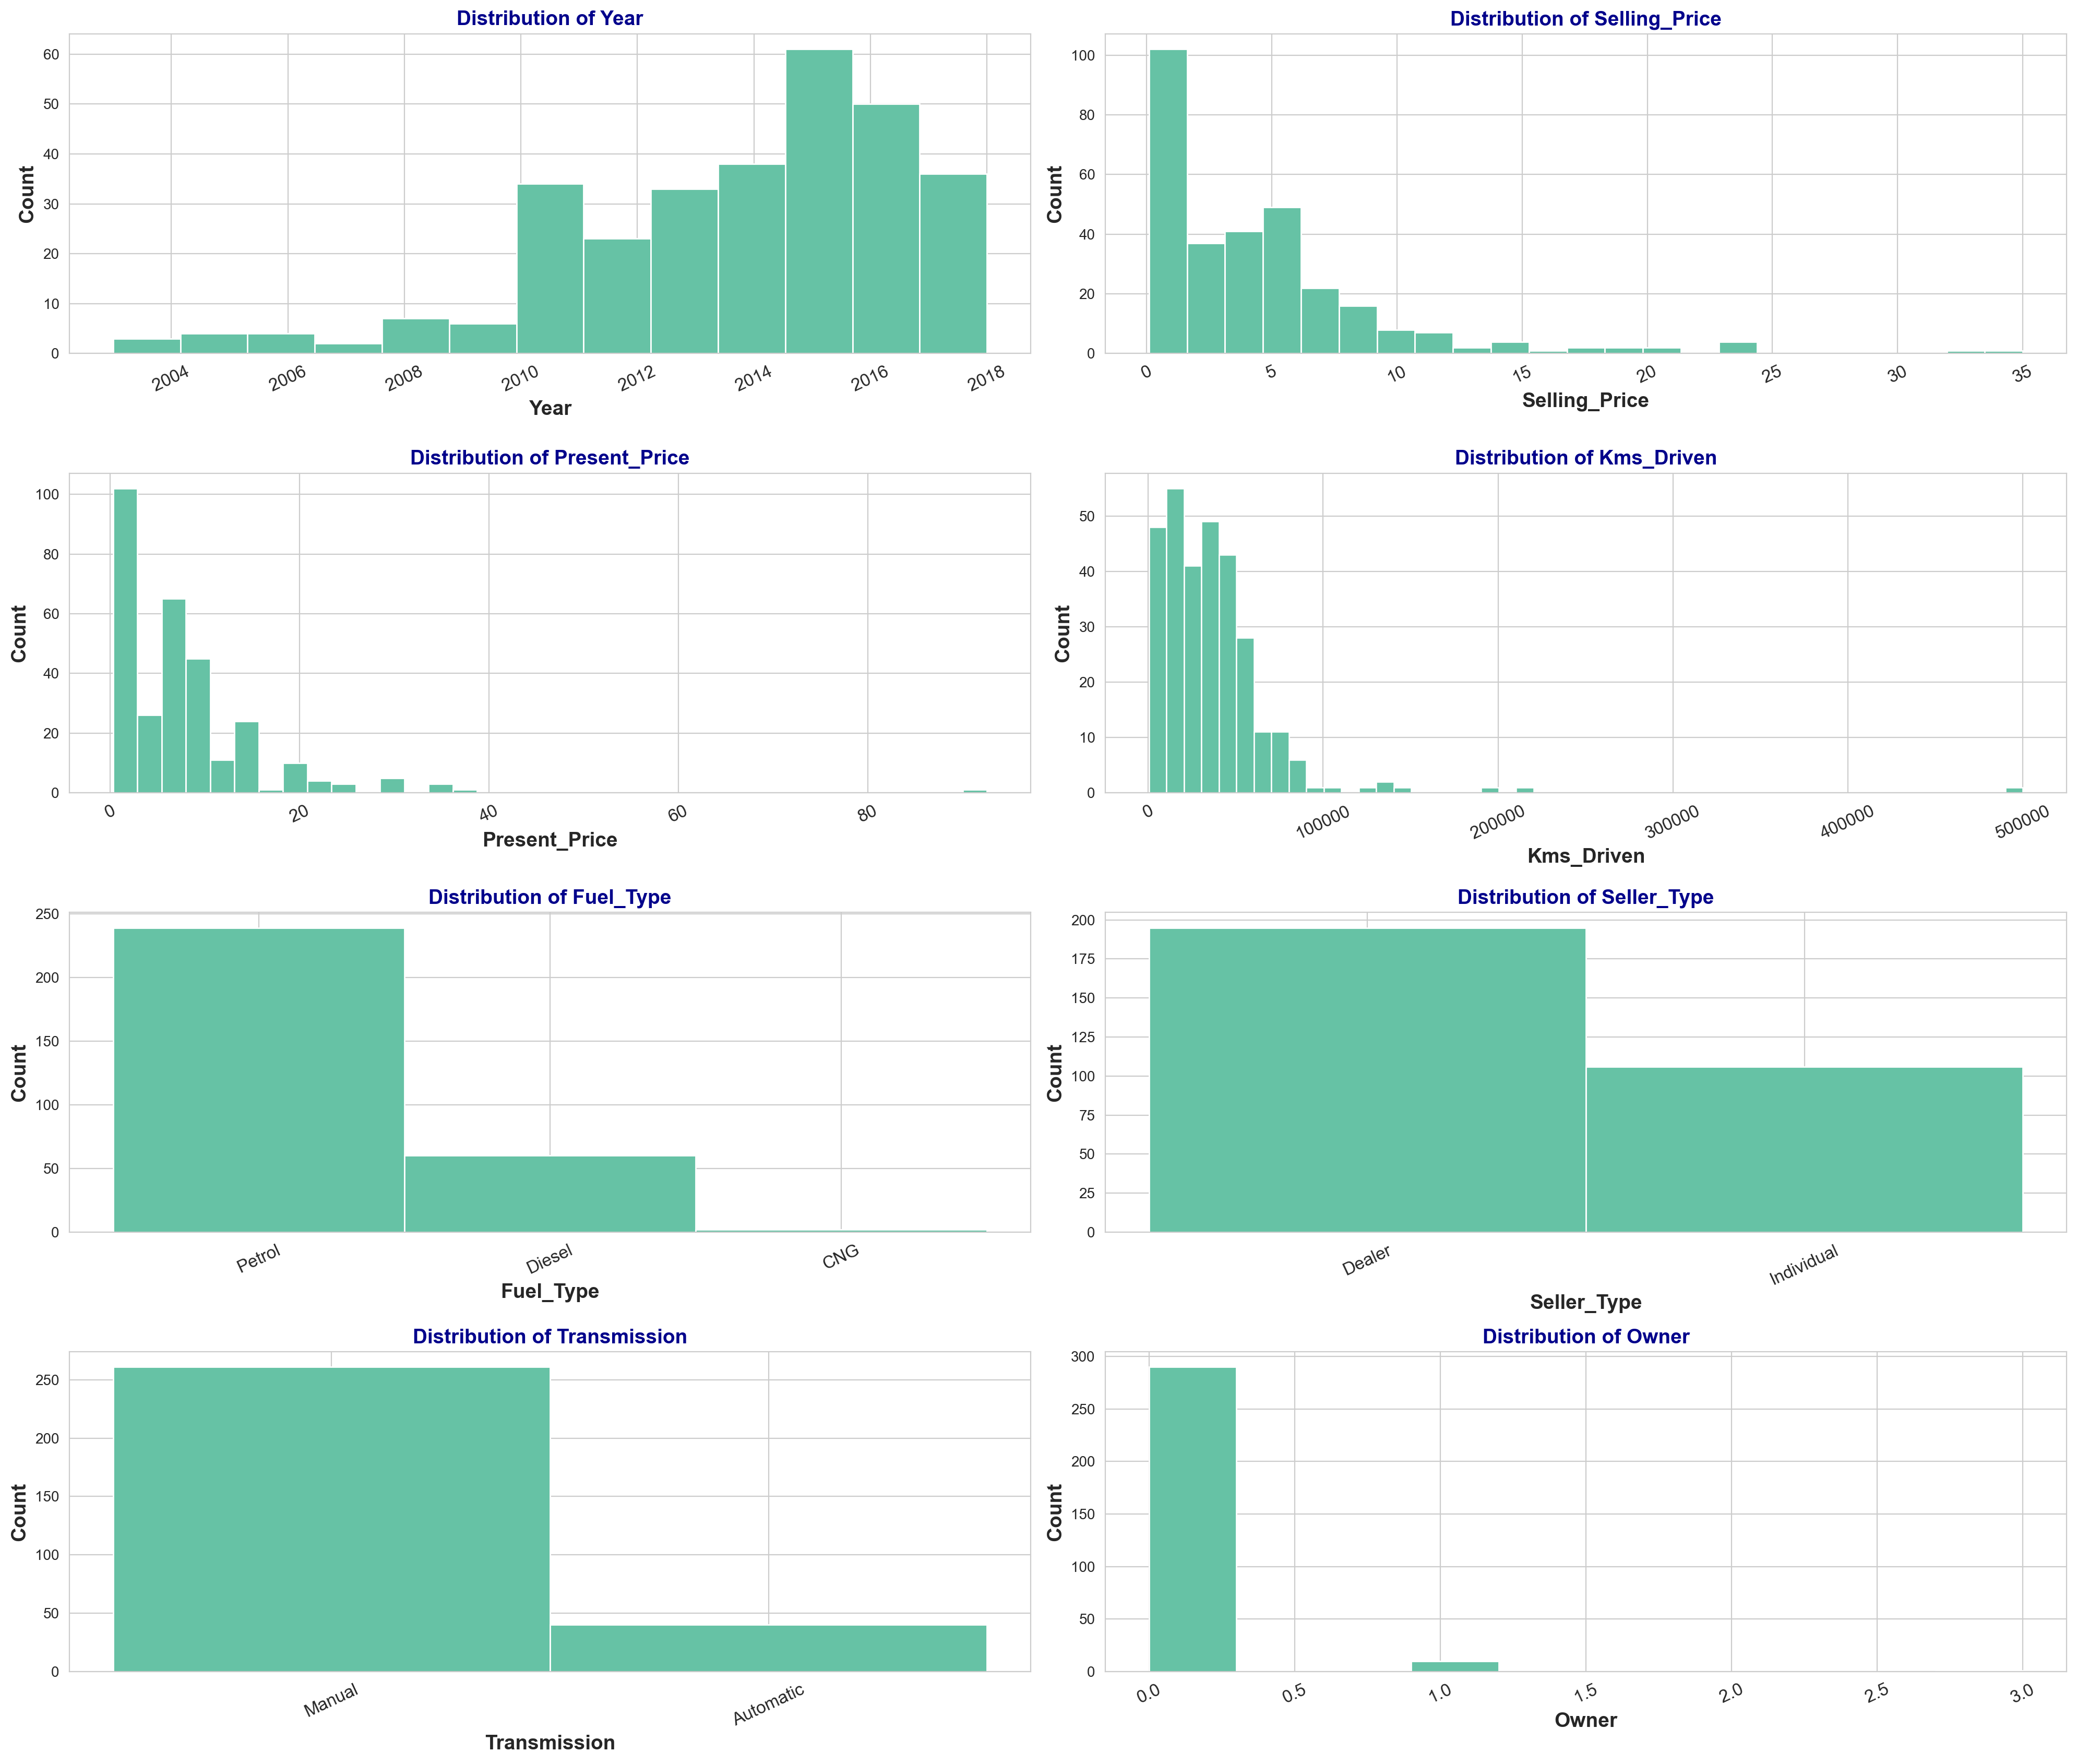

In [165]:
# Check data distribution
sns.set_style(style="whitegrid")
sns.set_palette(palette="Set2")


fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(20, 17), dpi=200)
columns = df.columns[:8]
ax = ax.flatten()



for i, col in enumerate(columns):
    sns.histplot(data=df, x=df[col], ax=ax[i], alpha=1)
    ax[i].set_title(
        f"Distribution of {col}", fontsize=14, fontweight="bold", color="darkblue"
    )


    ax[i].set_xlabel(col, fontweight="bold", fontsize=14)

    ax[i].set_ylabel("Count", fontweight="bold", fontsize=14)
    ax[i].tick_params(axis="x", rotation=25, labelsize=12)

plt.tight_layout()
plt.show()

<font size=8>
Year:<br>
The year distribution is from 2004 to 2018<br>
Most of the cars are from newer years (2013 to 2017)<br><br>
Selling Price:<br>
Most cars are priced very low.<br>
Only a few cars are priced higher (up to about 35).<br>
The distribution is Right-Skewed (most of the data is concentrated to the left).<br><br>
Present Price:<br>
The current price of most cars is less than 20.<br>
We have a few outliers that have gone up to 80.<br>
This means that the dataset includes some luxury or very expensive cars.<br><br>
Kms Driven:<br>
Most cars have less than 100,000 km.<br>
We have a few extreme outliers (up to 500,000 km).<br><br>

Fuel Type:<br>
Most cars are petrol.<br>
Then diesel.<br>
CNG is very rare.<br>
So the fuel type of most of the data is petrol → the learning model may have a bias towards petrol.<br><br>

Seller Type:<br>
Most sellers are Dealers.<br>
There are a few Individual sellers.<br>
This difference can affect the price (Dealers usually sell more expensively).<br><br>

Transmission:<br>
Most cars are manual.<br>
Fewer are automatic.<br>
Again, the model learns most of the data from manual.<br><br>

Owner:<br>
Most machines have only 1 owner (Owner=0 → first-hand).<br>
Very few machines have been changed hands twice or thrice.<br>
This means that the dataset mostly consists of relatively low-performance, first-hand machines.

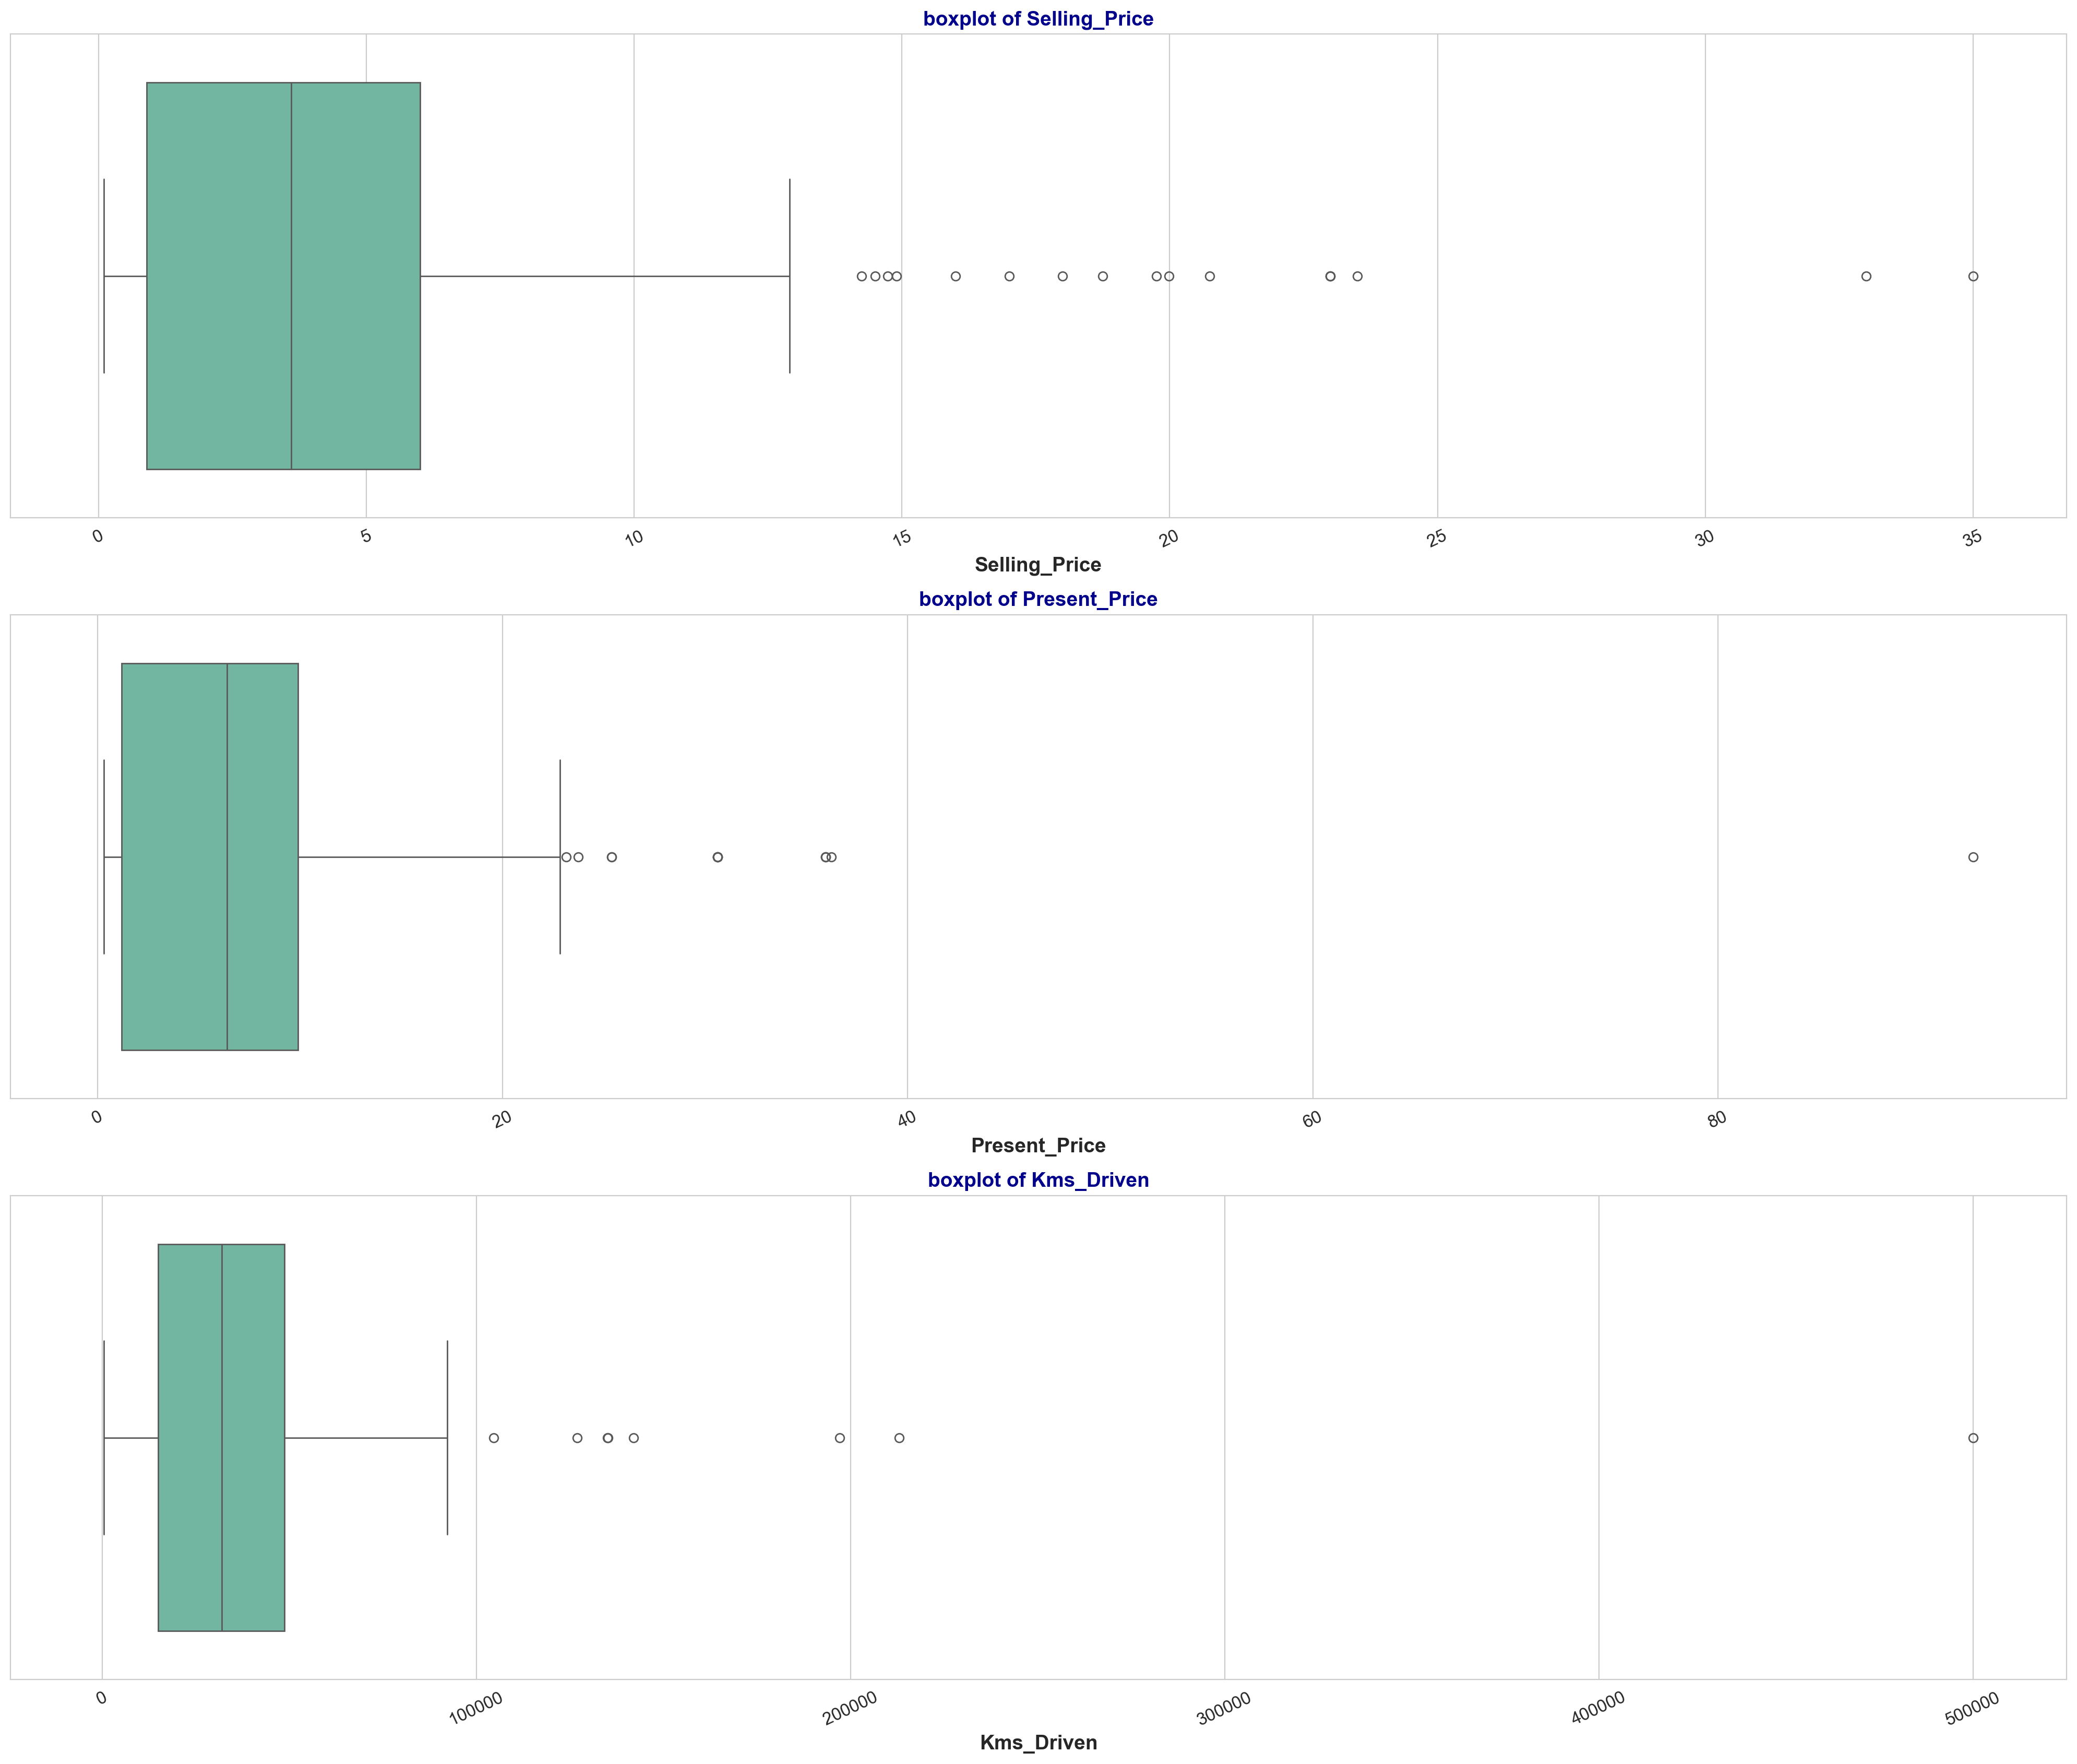

In [166]:
sns.set_style(style="whitegrid")
sns.set_palette(palette="Set2")


fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(20, 17), dpi=200)
columns = df.columns[1:4]
ax = ax.flatten()
for i, col in enumerate(columns):
    sns.boxplot(data=df, x=df[col], ax=ax[i])
    ax[i].set_title(
        f"boxplot of {col}", fontsize=14, fontweight="bold", color="darkblue"
    )
    ax[i].set_xlabel(col, fontweight="bold", fontsize=14)
    ax[i].tick_params(axis="x", rotation=25, labelsize=12)

plt.tight_layout()
plt.show()

In [167]:
# encoding  catrgorical feature
df2.replace({"Fuel_Type": {"Petrol": 2, "Diesel": 3, "CNG": 4}}, inplace=True)
df2.replace({"Seller_Type": {"Dealer": 2, "Individual": 3}}, inplace=True)
df2.replace({"Transmission": {"Manual": 2, "Automatic": 3}}, inplace=True)

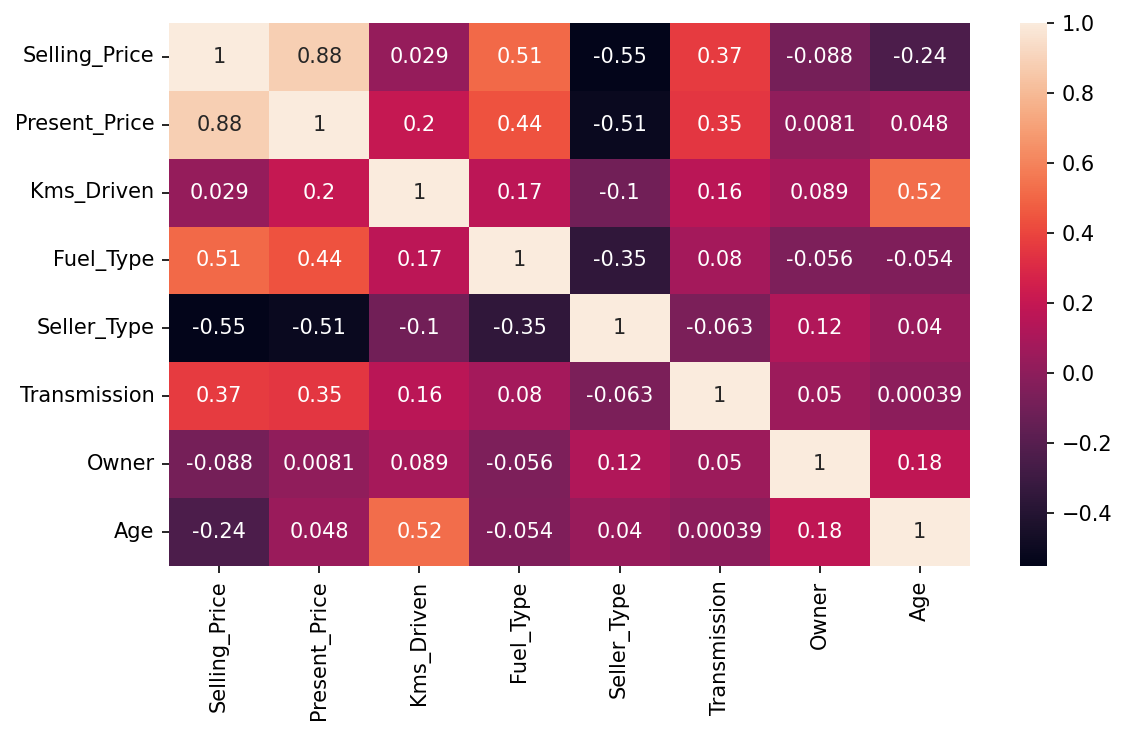

In [168]:
plt.style.use("default")  
plt.figure(figsize=(8, 5), dpi=150)
sns.heatmap(data=df2.corr(numeric_only=True), annot=True)
plt.tight_layout()
plt.show()

The biggest impact on selling_price:<br>
Present_Price > Seller_Type > Fuel_Type > Age > Transmission

In [169]:
fig = px.scatter(
    data_frame=df,
    x="Year",
    y="Selling_Price",
    height=600,
    width=1400,
    color_continuous_scale="viridis",
    size_max=12,
    title="Year vs Selling_Price",
)
fig.update_layout(
    title=dict(
        x=0.5,
        y=0.95,
        xanchor="center",
        yanchor="top",
        font=dict(size=24, color="black", family="Arial Black"),
    )
)
fig.update_layout(plot_bgcolor="white", paper_bgcolor="lightgray")
fig.update_traces(marker=dict(size=12))
fig.update_xaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.update_yaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.show()

Some years have very little data (1 data)<br>
Outliers are seen (samples 33 and 35)

In [170]:
fig = px.scatter(
    data_frame=df,
    x="Year",
    y="Selling_Price",
    height=600,
    width=1400,
    color=df["Selling_Price"] > 25,  # show Outlier
    color_continuous_scale="viridis",
    size_max=12,
    title="Year vs Selling_Price",
    labels={"color": "Outlier"},
)
fig.update_layout(legend_title_text="Outlier")
fig.update_layout(
    title=dict(
        x=0.5,
        y=0.95,
        xanchor="center",
        yanchor="top",
        font=dict(size=24, color="black", family="Arial Black"),
    )
)
fig.update_layout(plot_bgcolor="white", paper_bgcolor="lightgray")
fig.update_traces(marker=dict(size=12))
fig.update_xaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.update_yaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.show()

In [171]:
fig = px.scatter(
    data_frame=df,
    x="Present_Price",
    y="Selling_Price",
    height=700,
    width=1400,
    color_continuous_scale="viridis",
    size_max=15,
    title="Present_Price vs Selling_Price",
)
fig.update_layout(
    title=dict(
        x=0.5,
        y=0.95,
        xanchor="center",
        yanchor="top",
        font=dict(size=24, color="black", family="Arial Black"),
    )
)
fig.update_layout(plot_bgcolor="white", paper_bgcolor="lightgray")
fig.update_traces(marker=dict(size=12))
fig.update_xaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.update_yaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.show()

It is clearly seen that they have a linear relationship<br>
Outliers (samples 36 and 92)

In [172]:
fig = px.scatter(
    data_frame=df,
    x="Kms_Driven",
    y="Selling_Price",
    height=700,
    width=1400,
    color_continuous_scale="viridis",
    size_max=15,
    title="Kms_Driven vs Selling_Price",
)
fig.update_layout(
    title=dict(
        x=0.5,
        y=0.95,
        xanchor="center",
        yanchor="top",
        font=dict(size=24, color="black", family="Arial Black"),
    )
)
fig.update_layout(plot_bgcolor="white", paper_bgcolor="lightgray")
fig.update_traces(marker=dict(size=12))
fig.update_xaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.update_yaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.show()

Outlier (Sample: 500k)

In [173]:
df.groupby(["Fuel_Type"])["Selling_Price"].mean().sort_values()

Fuel_Type
CNG        3.100000
Petrol     3.264184
Diesel    10.278500
Name: Selling_Price, dtype: float64

In [174]:
fig = px.bar(
    data_frame=df.groupby(["Fuel_Type"])["Selling_Price"].mean().reset_index(),
    x="Fuel_Type",
    y="Selling_Price",
    title="Fuel_Type vs Selling_Price",
    height=700,
    width=1400
)
fig.update_layout(
    title=dict(
        x=0.5,
        y=0.95,
        xanchor="center",
        yanchor="top",
        font=dict(size=24, color="black", family="Arial Black"),
    )
)
fig.update_layout(plot_bgcolor="white", paper_bgcolor="lightgray")
fig.update_xaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.update_yaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.show()

In this data:<br>
Diesel has a higher average price<br>
But in principle gasoline cars have a higher price.

In [175]:
fig = px.bar(
    data_frame=df.groupby(["Seller_Type"])["Selling_Price"].mean().reset_index(),
    x="Seller_Type",
    y="Selling_Price",
    title="Seller_Type vs Selling_Price",
    height=700,
    width=1400,
)
fig.update_layout(
    title=dict(
        x=0.5,
        y=0.95,
        xanchor="center",
        yanchor="top",
        font=dict(size=24, color="black", family="Arial Black"),
    )
)
fig.update_layout(plot_bgcolor="white", paper_bgcolor="lightgray")
fig.update_xaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.update_yaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.show()

It is natural that the broker has a higher average price

In [176]:
fig = px.bar(
    data_frame=df.groupby(["Transmission"])["Selling_Price"].mean().reset_index(),
    x="Transmission",
    y="Selling_Price",
    title="Transmission vs Selling_Price",
    height=700,
    width=1400,
)
fig.update_layout(
    title=dict(
        x=0.5,
        y=0.95,
        xanchor="center",
        yanchor="top",
        font=dict(size=24, color="black", family="Arial Black"),
    )
)
fig.update_layout(plot_bgcolor="white", paper_bgcolor="lightgray")
fig.update_xaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.update_yaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.show()

In [177]:
fig = px.bar(
    data_frame=df2.groupby(["Age"])["Kms_Driven"].mean().reset_index(),
    x="Age",
    y="Kms_Driven",
    height=700,
    width=1400,
    title="Age vs Kms_Driven",
)
fig.update_layout(
    title=dict(
        x=0.5,
        y=0.95,
        xanchor="center",
        yanchor="top",
        font=dict(size=24, color="black", family="Arial Black"),
    )
)
fig.update_layout(plot_bgcolor="white", paper_bgcolor="lightgray")
fig.update_xaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.update_yaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.show()

The age chart with Kms_Driven has an almost correct distribution and it is logical that the older the car, the greater the distance traveled by it

# Cleaning outliers

In [178]:
outlier_Selling_Price = df2[df["Selling_Price"] >= 30].index
outlier_Kms_Driven = df2[df["Kms_Driven"] >= 500000].index
Outlier = outlier_Selling_Price.union(outlier_Kms_Driven)
df2.drop(Outlier, inplace=True)

# model

In [179]:
x = df2.drop(columns=["Selling_Price"], axis=1)
y = df2["Selling_Price"]

In [180]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [181]:
model_1 = LinearRegression()
model_1.fit(x_train, y_train)

LinearRegression()

In [182]:
y_pred = model_1.predict(x_test)

In [183]:
print(f"model_1 coef:\n{model_1.coef_}")
print(f"model_1 intercept:\n{model_1.intercept_}")

model_1 coef:
[ 5.26548777e-01 -2.09352877e-05  1.26602869e+00 -7.52619932e-01
  4.88794630e-01 -9.65657934e-01 -3.07946244e-01]
model_1 intercept:
1.006973775747534


In [184]:
print(f"mean absolute error 'model_1':\n{mean_absolute_error(y_test, y_pred)}")
print(f"mean squared error 'model_1':\n{mean_squared_error(y_test, y_pred)}")
print(f"root mean squared error 'model_1':\n{root_mean_squared_error(y_test, y_pred)}")
print(f"r2 score 'model_1':\n{r2_score(y_test, y_pred)}")

mean absolute error 'model_1':
0.9439120078953491
mean squared error 'model_1':
1.5526229786216297
root mean squared error 'model_1':
1.2460429280813843
r2 score 'model_1':
0.9315874970346788


In [185]:
compare_1 = pd.DataFrame(
    data={
        "Actual":y_test,
        "Predict":y_pred.flatten()
    }
)
compare_1

,Actual,Predict
113,1.15,1.339355
177,0.35,1.621402
12,7.50,7.188256
221,4.50,4.557835
208,7.90,6.588620
75,3.95,4.606457
213,2.90,3.461438
175,0.38,-1.360562
191,0.20,-1.085770
219,4.50,5.051645


In [186]:
df4 = x_test
df4

,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
113,1.400,35000,2,3,2,0,3
177,0.570,24000,2,3,3,0,3
12,9.940,15000,2,2,3,0,4
221,6.790,32000,2,2,3,0,6
208,8.100,3435,2,2,2,0,2
75,6.800,36000,2,2,2,0,4
213,6.790,31604,2,2,2,0,8
175,0.787,75000,2,3,2,0,8
191,0.570,25000,2,3,2,1,7
219,9.400,36000,2,2,2,0,7


In [187]:
df4.insert(7, "y_test", y_test)
df4.insert(8, "y_pred", y_pred)

In [188]:
df4.sort_values(by="Present_Price", inplace=True)
df4

,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age,y_test,y_pred
183,0.470,21000,2,3,2,0,6,0.27,0.218920
181,0.480,50000,2,3,2,0,3,0.30,0.540901
173,0.510,1300,2,3,3,0,2,0.40,2.372987
169,0.540,14000,2,3,2,0,4,0.40,1.018218
177,0.570,24000,2,3,3,0,3,0.35,1.621402
191,0.570,25000,2,3,2,1,7,0.20,-1.085770
192,0.750,49000,2,3,2,1,12,0.20,-3.033170
190,0.750,60000,2,3,2,0,11,0.20,-1.989854
175,0.787,75000,2,3,2,0,8,0.38,-1.360562
137,0.787,16000,2,3,2,0,6,0.65,0.490512


In [189]:
fig = px.scatter(data_frame=df4, x=y_test, y=y_pred, height=600, width=1400, size_max=15)
fig.update_layout(
    xaxis_title="y_test",
    yaxis_title="y_predict"
)
fig.update_traces(marker=dict(size=12))
fig.show()

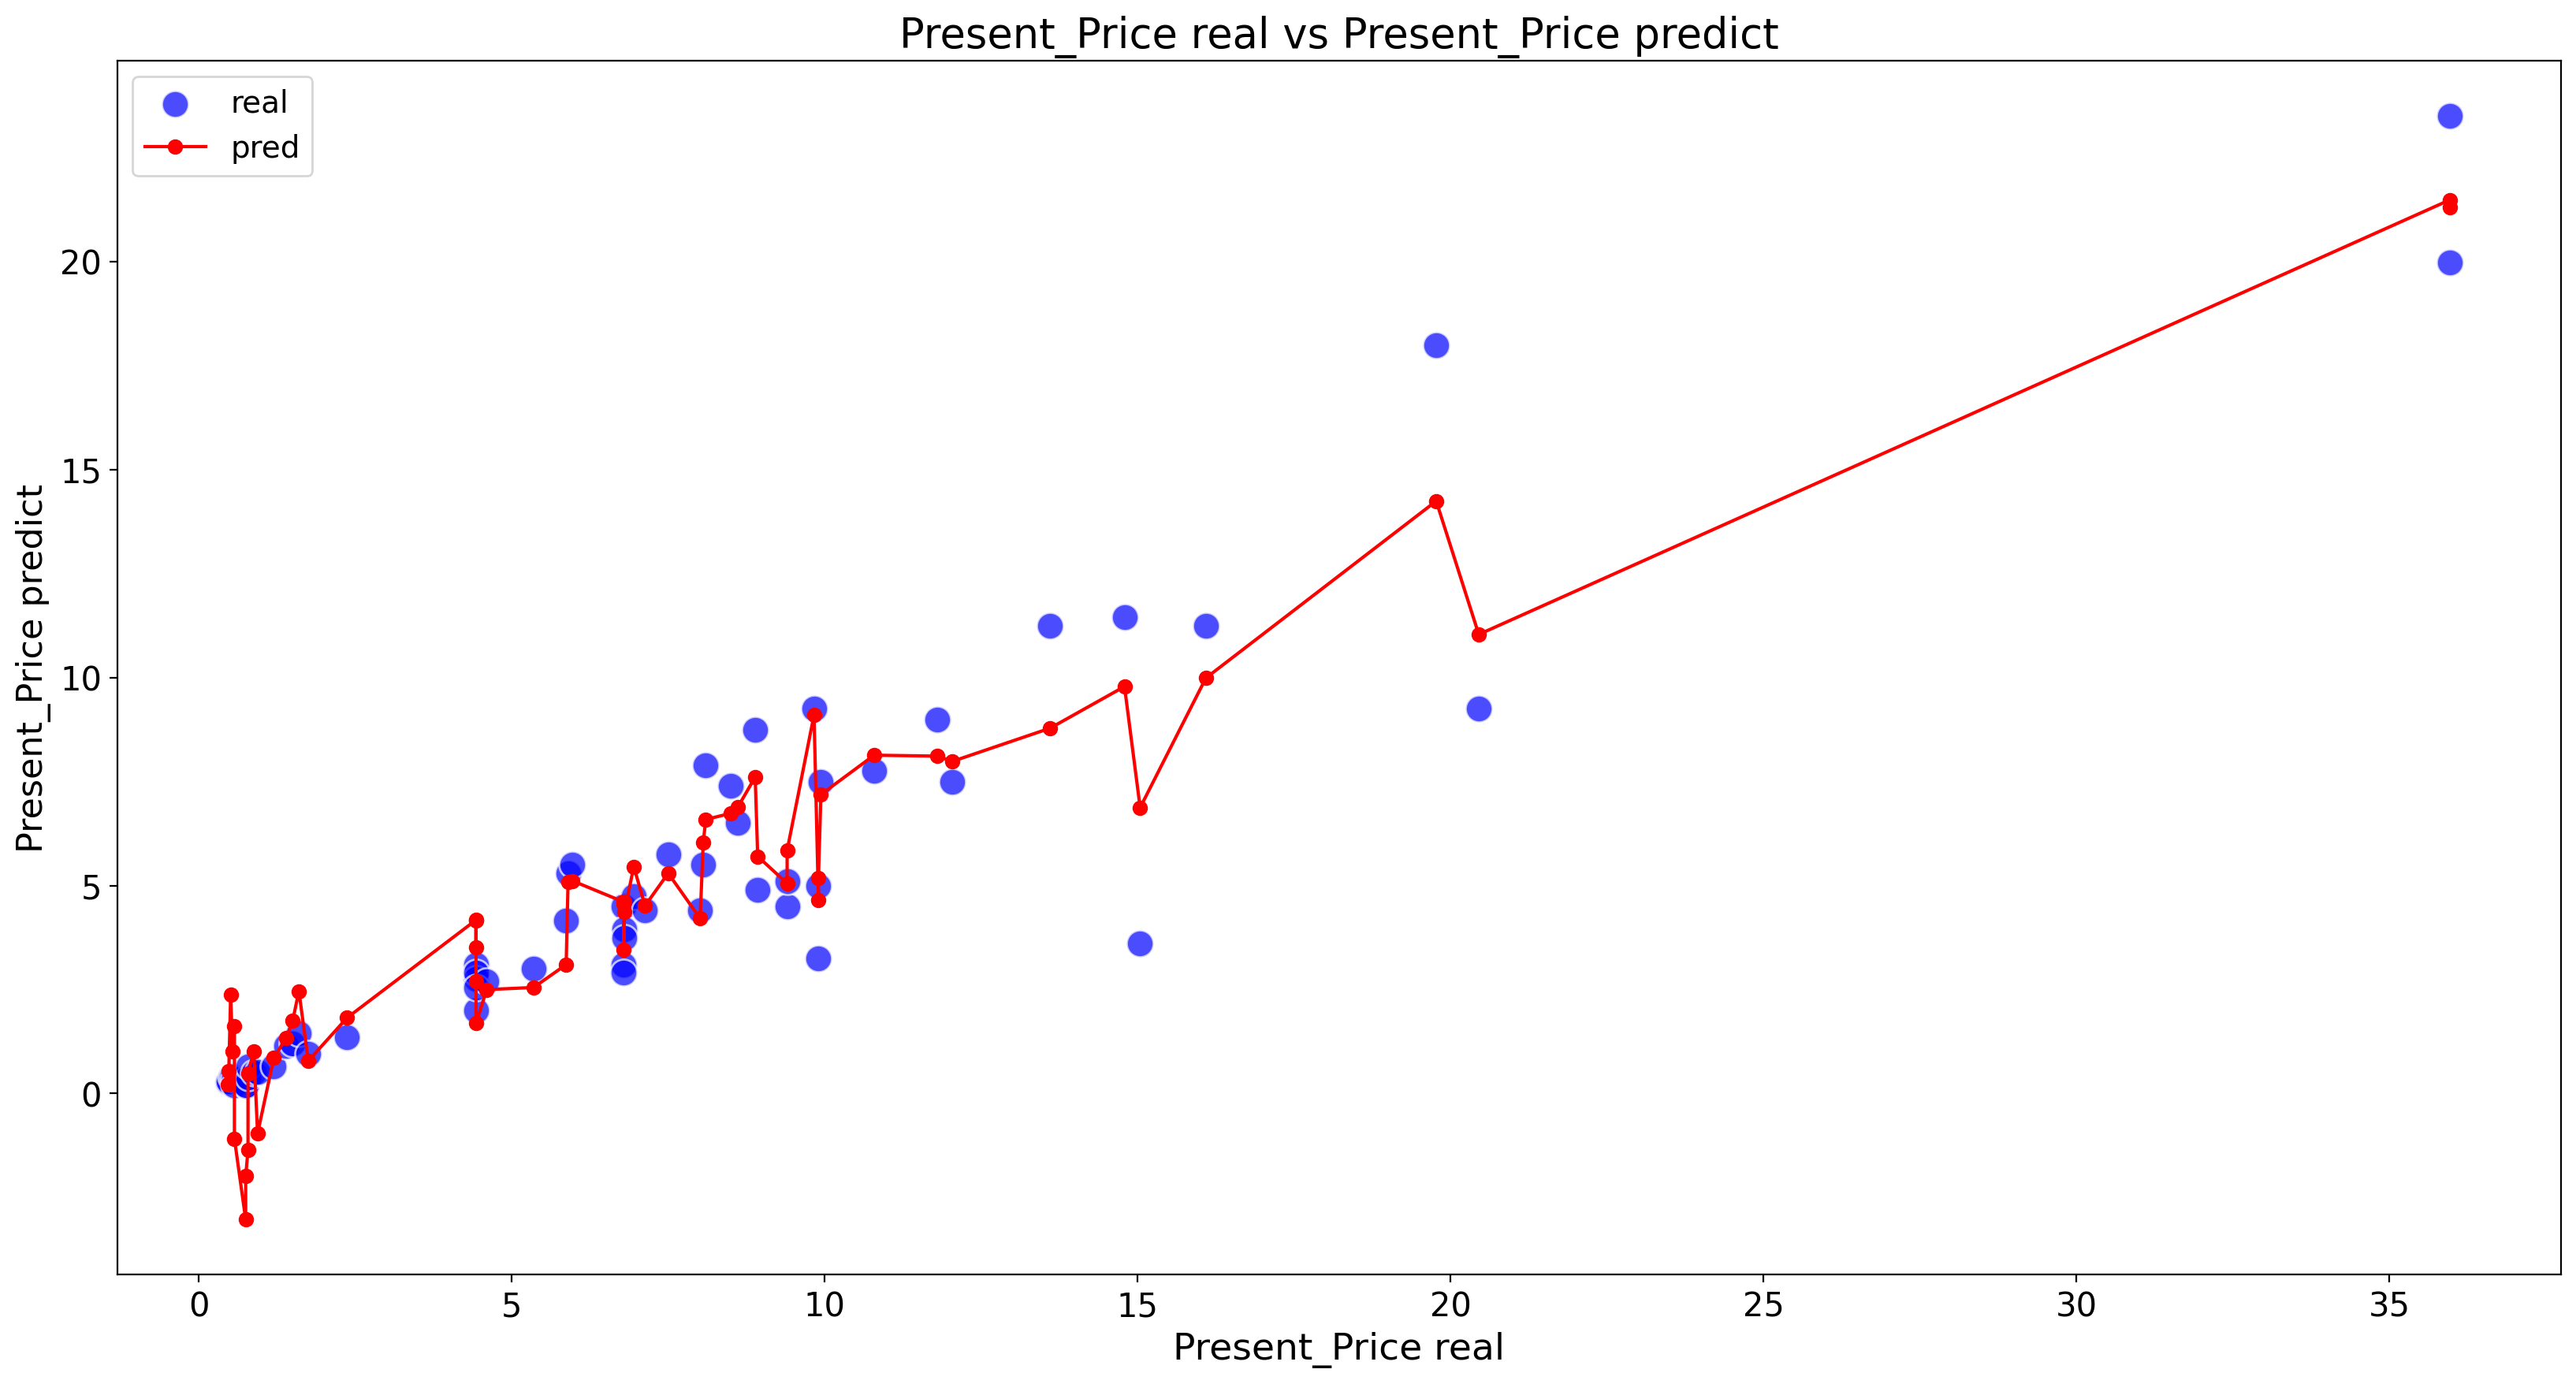

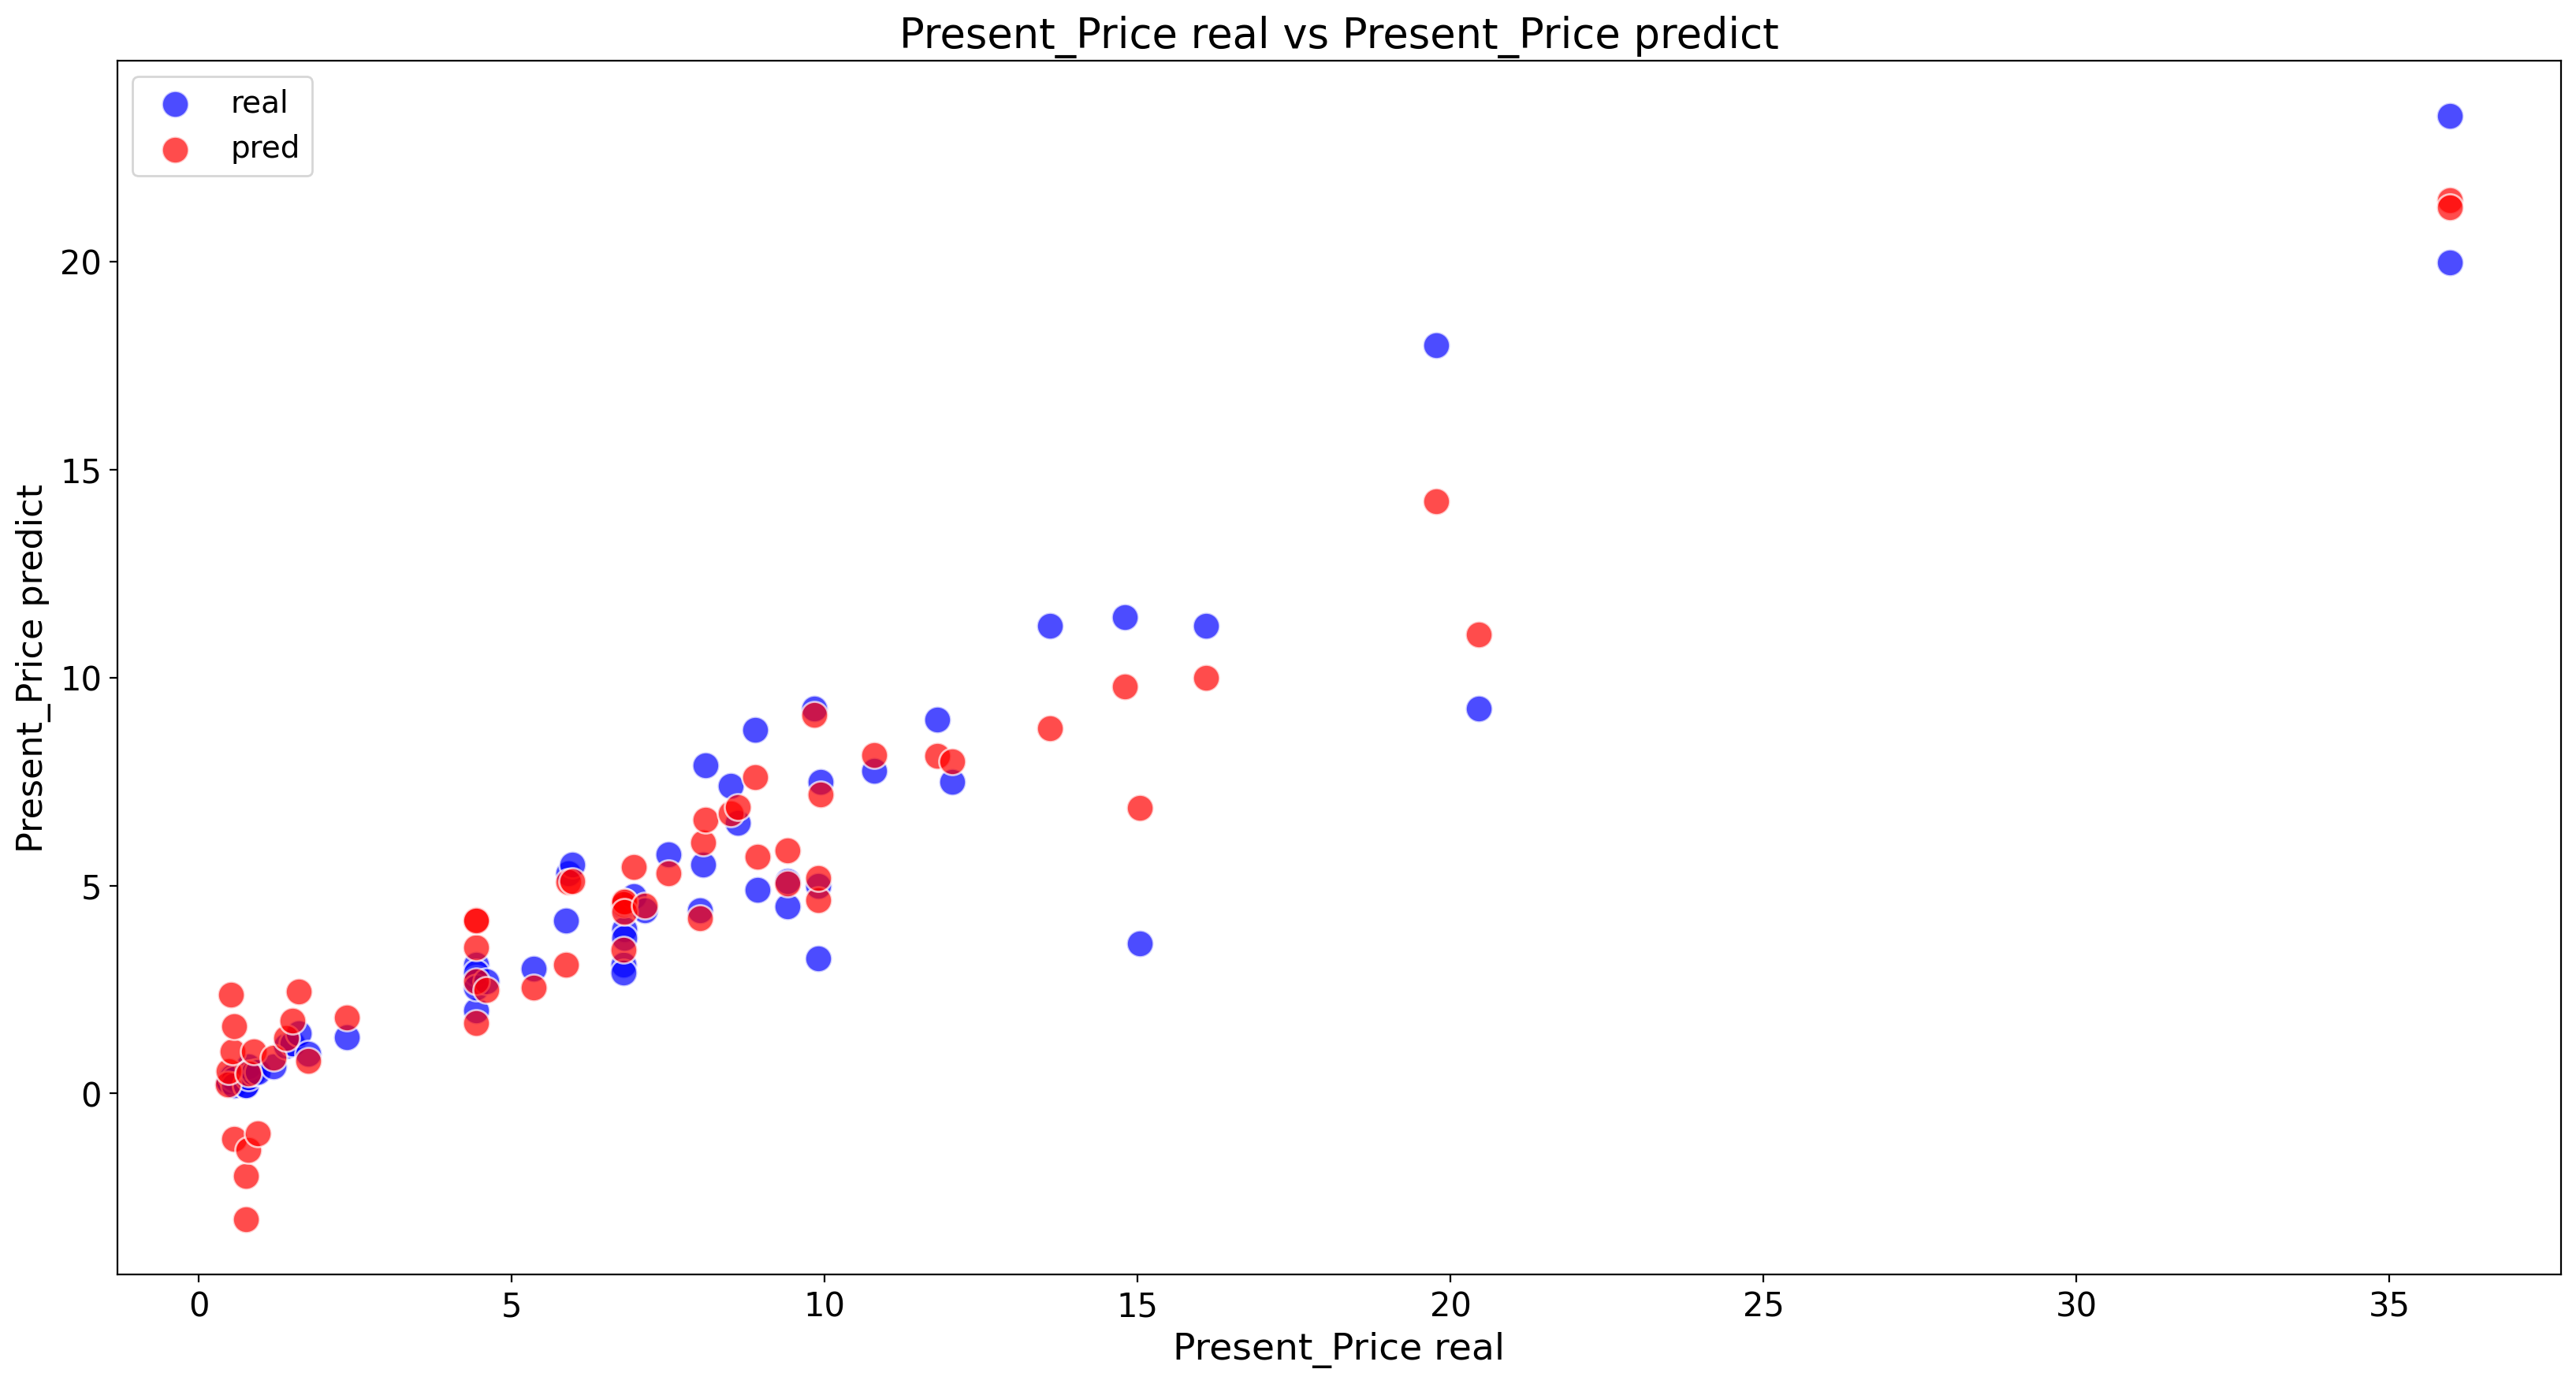

In [190]:
plt.figure(figsize=(20, 10), dpi=200)
sns.scatterplot(
    x=df4["Present_Price"],
    y=df4["y_test"],
    s=150,
    color="blue",
    alpha=0.7,
    label="real",
)
plt.plot(df4["Present_Price"], df4["y_pred"], color="red", marker="o", label="pred")
plt.title("Present_Price real vs Present_Price predict", fontsize=19)
plt.xlabel("Present_Price real", fontsize=17)
plt.ylabel("Present_Price predict", fontsize=16)
plt.tick_params(axis="both", labelsize=15)
plt.legend(title_fontsize=15, fontsize=14)
plt.show()
plt.figure(figsize=(20, 10), dpi=200)
sns.scatterplot(
    x=df4["Present_Price"],
    y=df4["y_test"],
    s=150,
    color="blue",
    alpha=0.7,
    label="real",
)
sns.scatterplot(
    x=df4["Present_Price"], y=df4["y_pred"], color="red", s=150, alpha=0.7, label="pred"
)
plt.title("Present_Price real vs Present_Price predict", fontsize=19)
plt.xlabel("Present_Price real", fontsize=17)
plt.ylabel("Present_Price predict", fontsize=16)
plt.tick_params(axis="both", labelsize=15)
plt.legend(title_fontsize=15, fontsize=14)
plt.show()

The accuracy of the model is not bad, but the line fit is not good and negative values ​​are predicted, which is bad<br>
Let's improve the accuracy of the model

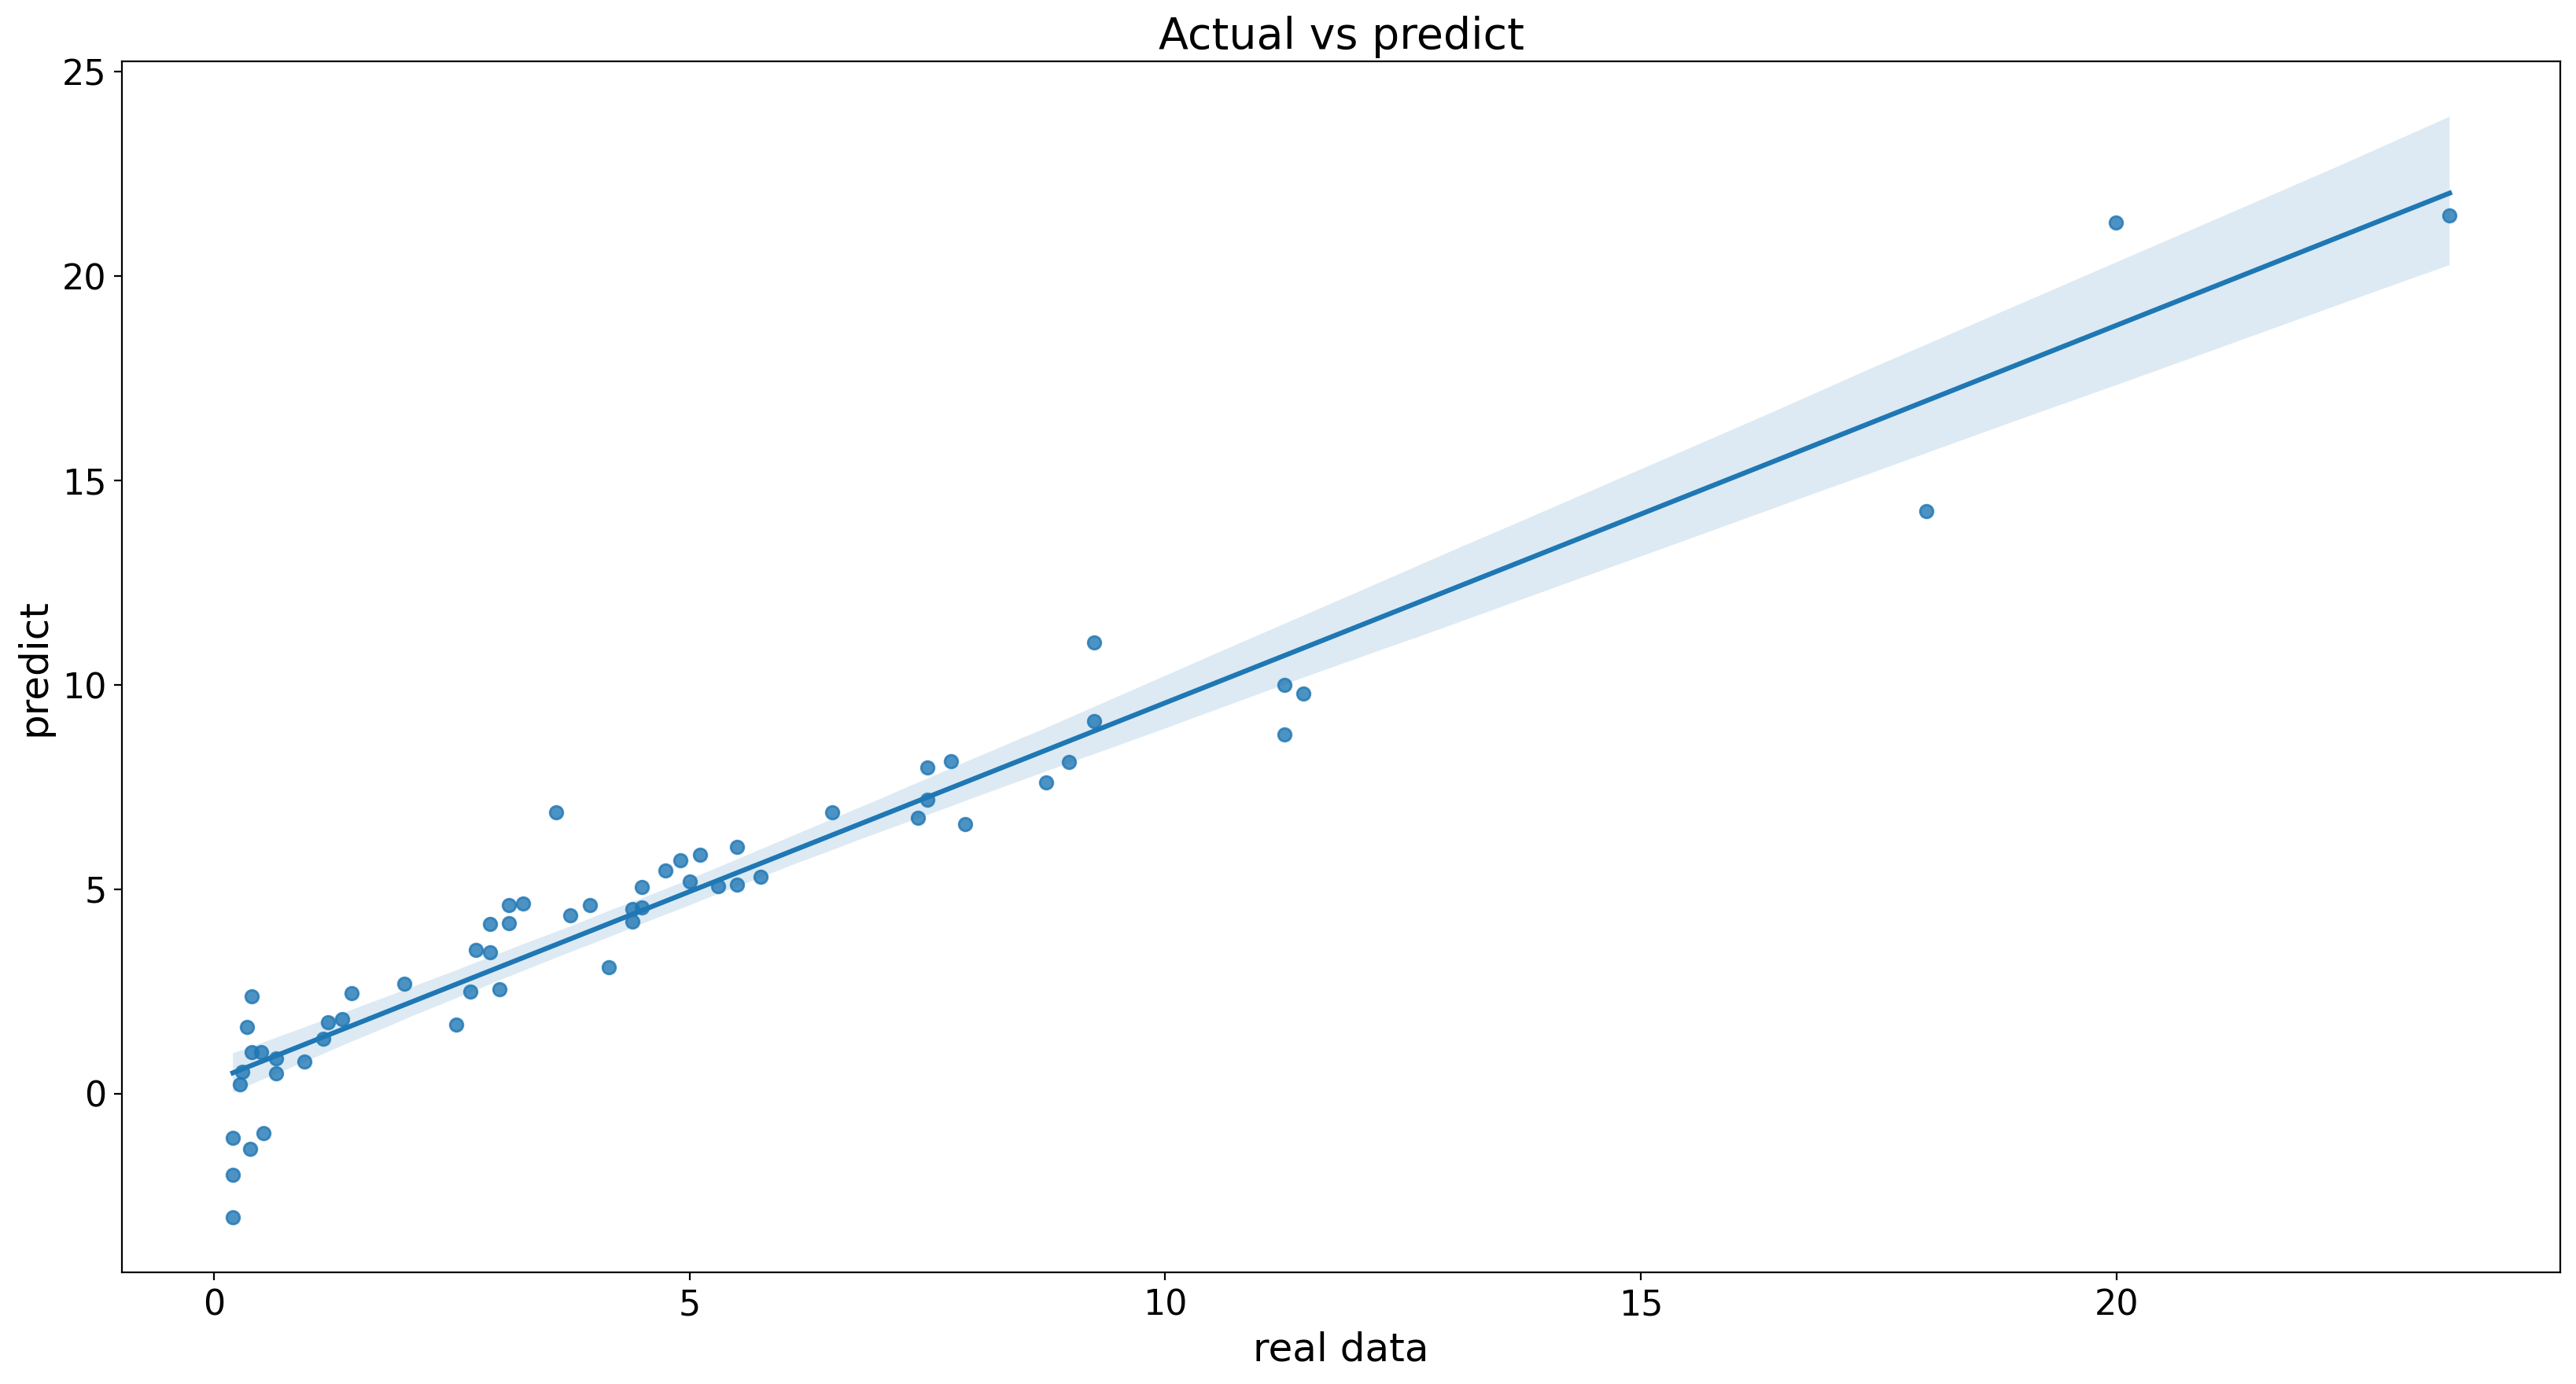

In [191]:
plt.figure(figsize=(20, 10), dpi=200)
sns.regplot(x=y_test, y=y_pred)
plt.title("Actual vs predict", fontsize=20)
plt.xlabel("real data", fontsize=18)
plt.ylabel("predict", fontsize=18)
plt.tick_params(axis="both", labelsize=16)
plt.show()

In [192]:
Present_Price_2 = df2.Present_Price**2
df2.insert(2, "Present_Price_2", Present_Price_2)
df2

,Selling_Price,Present_Price,Present_Price_2,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,31.2481,27000,2,2,2,0,5
1,4.75,9.54,91.0116,43000,3,2,2,0,6
2,7.25,9.85,97.0225,6900,2,2,2,0,2
3,2.85,4.15,17.2225,5200,2,2,2,0,8
4,4.60,6.87,47.1969,42450,3,2,2,0,5
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,134.5600,33988,3,2,2,0,3
297,4.00,5.90,34.8100,60000,2,2,2,0,4
298,3.35,11.00,121.0000,87934,2,2,2,0,10
299,11.50,12.50,156.2500,9000,3,2,2,0,2


In [193]:
x = df2.drop(columns=["Selling_Price"])
y = df2["Selling_Price"]

In [194]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [195]:
model_2 = LinearRegression()
model_2.fit(x_train, y_train)

LinearRegression()

In [196]:
y_pred = model_2.predict(x_test)

In [197]:
print(f"model_2 coef:\n{model_2.coef_}")
print(f"model_2 intercept:\n{model_2.intercept_}")

model_2 coef:
[ 4.93242238e-01  1.14735553e-03 -2.08306351e-05  1.25530793e+00
 -8.99523369e-01  4.13611834e-01 -9.40645989e-01 -3.07671365e-01]
model_2 intercept:
1.656379579809018


In [198]:
print(f"mean absolute error 'model_2':\n{mean_absolute_error(y_test, y_pred)}")
print(f"mean squared error 'model_2':\n{mean_squared_error(y_test, y_pred)}")
print(f"root mean squared error 'model_2':\n{root_mean_squared_error(y_test, y_pred)}")
print(f"r2 score 'model_2':\n{r2_score(y_test, y_pred)}")

mean absolute error 'model_2':
0.9439318655104003
mean squared error 'model_2':
1.5525157070199604
root mean squared error 'model_2':
1.2459998824317602
r2 score 'model_2':
0.931592223693287


The accuracy of the model did not change, so I will drop it.

In [199]:
df2.drop(columns=["Present_Price_2"], inplace=True)

In [200]:
Fuel_Type_2= df2.Fuel_Type**2
df2.insert(4,'Fuel_Type_2', Fuel_Type_2)
df2

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Fuel_Type_2,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000,2,4,2,2,0,5
1,4.75,9.54,43000,3,9,2,2,0,6
2,7.25,9.85,6900,2,4,2,2,0,2
3,2.85,4.15,5200,2,4,2,2,0,8
4,4.60,6.87,42450,3,9,2,2,0,5
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,3,9,2,2,0,3
297,4.00,5.90,60000,2,4,2,2,0,4
298,3.35,11.00,87934,2,4,2,2,0,10
299,11.50,12.50,9000,3,9,2,2,0,2


In [201]:
x = df2.drop(columns=["Selling_Price"])
y = df2["Selling_Price"]

In [202]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [203]:
model_3 = LinearRegression()
model_3.fit(x_train, y_train)

LinearRegression()

In [204]:
y_pred = model_3.predict(x_test)

In [205]:
print(f"model_3 coef:\n{model_3.coef_}")
print(f"model_3 intercept:\n{model_3.intercept_}")

model_3 coef:
[ 5.13817293e-01 -2.21198032e-05  1.13965516e+01 -1.94274265e+00
 -8.07665428e-01  5.29793090e-01 -9.37092260e-01 -2.95558328e-01]
model_3 intercept:
-11.423767810850295


In [206]:
print(f"mean absolute error 'model_3':\n{mean_absolute_error(y_test, y_pred)}")
print(f"mean squared error 'model_3':\n{mean_squared_error(y_test, y_pred)}")
print(f"root mean squared error 'model_3':\n{root_mean_squared_error(y_test, y_pred)}")
print(f"r2 score 'model_3':\n{r2_score(y_test, y_pred)}")

mean absolute error 'model_3':
0.9582443181784597
mean squared error 'model_3':
1.5474834886997593
root mean squared error 'model_3':
1.2439788939928842
r2 score 'model_3':
0.9318139559847017


It didn't change, so I'll drop it.

In [207]:
df2.drop(columns=["Fuel_Type_2"], inplace=True)

In [208]:
Transmission_2= df2.Transmission**2
df2.insert(6,'Transmission_2',Transmission_2)
df2

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Transmission_2,Owner,Age
0,3.35,5.59,27000,2,2,2,4,0,5
1,4.75,9.54,43000,3,2,2,4,0,6
2,7.25,9.85,6900,2,2,2,4,0,2
3,2.85,4.15,5200,2,2,2,4,0,8
4,4.60,6.87,42450,3,2,2,4,0,5
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,3,2,2,4,0,3
297,4.00,5.90,60000,2,2,2,4,0,4
298,3.35,11.00,87934,2,2,2,4,0,10
299,11.50,12.50,9000,3,2,2,4,0,2


In [209]:
x = df2.drop(columns=["Selling_Price"])
y = df2["Selling_Price"]

In [210]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [211]:
model_4 = LinearRegression()
model_4.fit(x_train, y_train)

LinearRegression()

In [212]:
y_pred = model_4.predict(x_test)

In [213]:
print(f"model_4 coef:\n{model_4.coef_}")
print(f"model_4 intercept:\n{model_4.intercept_}")

model_4 coef:
[ 5.26548777e-01 -2.09352877e-05  1.26602869e+00 -7.52619932e-01
  1.87997935e-02  9.39989674e-02 -9.65657934e-01 -3.07946244e-01]
model_4 intercept:
1.570967580018455


In [214]:
print(f"mean absolute error 'model_4':\n{mean_absolute_error(y_test, y_pred)}")
print(f"mean squared error 'model_4':\n{mean_squared_error(y_test, y_pred)}")
print(f"root mean squared error 'model_4':\n{root_mean_squared_error(y_test, y_pred)}")
print(f"r2 score 'model_4':\n{r2_score(y_test, y_pred)}")

mean absolute error 'model_4':
0.9439120078953496
mean squared error 'model_4':
1.5526229786216301
root mean squared error 'model_4':
1.2460429280813845
r2 score 'model_4':
0.9315874970346787


drop it

In [215]:
df2.drop(columns=["Transmission_2"], inplace=True)

In [216]:
Owner_2= df2.Owner**2
df2.insert(7,'Owner_2',Owner_2)
df2

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Owner_2,Age
0,3.35,5.59,27000,2,2,2,0,0,5
1,4.75,9.54,43000,3,2,2,0,0,6
2,7.25,9.85,6900,2,2,2,0,0,2
3,2.85,4.15,5200,2,2,2,0,0,8
4,4.60,6.87,42450,3,2,2,0,0,5
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,3,2,2,0,0,3
297,4.00,5.90,60000,2,2,2,0,0,4
298,3.35,11.00,87934,2,2,2,0,0,10
299,11.50,12.50,9000,3,2,2,0,0,2


In [217]:
x = df2.drop(columns=["Selling_Price"])
y = df2["Selling_Price"]

In [218]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [219]:
model_5 = LinearRegression()
model_5.fit(x_train, y_train)

LinearRegression()

In [220]:
y_pred = model_5.predict(x_test)

In [221]:
print(f"model_5 coef:\n{model_5.coef_}")
print(f"model_5 intercept:\n{model_5.intercept_}")

model_5 coef:
[ 5.35008718e-01 -1.88468448e-05  1.20395804e+00 -6.51232108e-01
  5.66158753e-01  1.29020984e+00 -1.11831172e+00 -3.15192176e-01]
model_5 intercept:
0.6194732792287976


In [222]:
print(f"mean absolute error 'model_5':\n{mean_absolute_error(y_test, y_pred)}")
print(f"mean squared error 'model_5':\n{mean_squared_error(y_test, y_pred)}")
print(f"root mean squared error 'model_5':\n{root_mean_squared_error(y_test, y_pred)}")
print(f"r2 score 'model_5':\n{r2_score(y_test, y_pred)}")

mean absolute error 'model_5':
0.9012130773521806
mean squared error 'model_5':
1.4141672857489704
root mean squared error 'model_5':
1.1891876579198803
r2 score 'model_5':
0.9376882057254811


drop it

In [223]:
df2.drop(columns=["Owner_2"], inplace=True)

In [224]:
Age_2 = df2["Age"] ** 2
df2.insert(8, "Age_2", Age_2)
df2

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age,Age_2
0,3.35,5.59,27000,2,2,2,0,5,25
1,4.75,9.54,43000,3,2,2,0,6,36
2,7.25,9.85,6900,2,2,2,0,2,4
3,2.85,4.15,5200,2,2,2,0,8,64
4,4.60,6.87,42450,3,2,2,0,5,25
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,3,2,2,0,3,9
297,4.00,5.90,60000,2,2,2,0,4,16
298,3.35,11.00,87934,2,2,2,0,10,100
299,11.50,12.50,9000,3,2,2,0,2,4


In [225]:
x = df2.drop(columns=["Selling_Price"])
y = df2["Selling_Price"]

In [226]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [227]:
model_6 = LinearRegression()
model_6.fit(x_train, y_train)

LinearRegression()

In [228]:
y_pred = model_6.predict(x_test)

In [229]:
print(f"model_6 coef:\n{model_6.coef_}")
print(f"model_6 intercept:\n{model_6.intercept_}")

model_6 coef:
[ 5.26792735e-01 -2.16371717e-05  1.38584981e+00 -7.91546370e-01
  3.55213098e-01 -9.58730676e-01 -7.10442116e-01  2.77305836e-02]
model_6 intercept:
2.256674302065737


In [230]:
print(f"mean absolute error 'model_6':\n{mean_absolute_error(y_test, y_pred)}")
print(f"mean squared error 'model_6':\n{mean_squared_error(y_test, y_pred)}")
print(f"root mean squared error 'model_6':\n{root_mean_squared_error(y_test, y_pred)}")
print(f"r2 score 'model_6':\n{r2_score(y_test, y_pred)}")

mean absolute error 'model_6':
0.9614098816390796
mean squared error 'model_6':
1.53425186164545
root mean squared error 'model_6':
1.2386492084708447
r2 score 'model_6':
0.9323969750031968


drop it

In [231]:
df2.drop(columns=["Age_2"], inplace=True)

In [232]:
Kms_Driven_2= df2.Kms_Driven**2
df2.insert(4,'Kms_Driven_2',Kms_Driven_2)
df2

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Kms_Driven_2,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000,2,729000000,2,2,0,5
1,4.75,9.54,43000,3,1849000000,2,2,0,6
2,7.25,9.85,6900,2,47610000,2,2,0,2
3,2.85,4.15,5200,2,27040000,2,2,0,8
4,4.60,6.87,42450,3,1802002500,2,2,0,5
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,3,1155184144,2,2,0,3
297,4.00,5.90,60000,2,3600000000,2,2,0,4
298,3.35,11.00,87934,2,7732388356,2,2,0,10
299,11.50,12.50,9000,3,81000000,2,2,0,2


In [233]:
x = df2.drop(columns=["Selling_Price"])
y = df2["Selling_Price"]

In [234]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [235]:
model_7 = LinearRegression()
model_7.fit(x_train, y_train)

LinearRegression()

In [236]:
y_pred = model_7.predict(x_test)

In [237]:
print(f"model_7 coef:\n{model_7.coef_}")
print(f"model_7 intercept:\n{model_7.intercept_}")

model_7 coef:
[ 5.31843954e-01 -4.20594016e-05  1.34732354e+00  1.26921706e-10
 -9.26538083e-01  4.18159003e-01 -9.99128522e-01 -2.73199737e-01]
model_7 intercept:
1.648184518855528


In [238]:
print(f"mean absolute error 'model_7':\n{mean_absolute_error(y_test, y_pred)}")
print(f"mean squared error 'model_7':\n{mean_squared_error(y_test, y_pred)}")
print(f"root mean squared error 'model_7':\n{root_mean_squared_error(y_test, y_pred)}")
print(f"r2 score 'model_7':\n{r2_score(y_test, y_pred)}")

mean absolute error 'model_7':
0.9453235604360323
mean squared error 'model_7':
1.6256986944774914
root mean squared error 'model_7':
1.2750288994675734
r2 score 'model_7':
0.9283675958117042


Lower the accuracy, then it will be drop

In [239]:
df2.drop(columns=["Kms_Driven_2"], inplace=True)

In [240]:
df2

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000,2,2,2,0,5
1,4.75,9.54,43000,3,2,2,0,6
2,7.25,9.85,6900,2,2,2,0,2
3,2.85,4.15,5200,2,2,2,0,8
4,4.60,6.87,42450,3,2,2,0,5
...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,3,2,2,0,3
297,4.00,5.90,60000,2,2,2,0,4
298,3.35,11.00,87934,2,2,2,0,10
299,11.50,12.50,9000,3,2,2,0,2


In [241]:
Present_Kms= df2['Present_Price']*df2['Kms_Driven']
df2.insert(3,'Present_Kms',Present_Kms)
df2

,Selling_Price,Present_Price,Kms_Driven,Present_Kms,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000,150930.0,2,2,2,0,5
1,4.75,9.54,43000,410220.0,3,2,2,0,6
2,7.25,9.85,6900,67965.0,2,2,2,0,2
3,2.85,4.15,5200,21580.0,2,2,2,0,8
4,4.60,6.87,42450,291631.5,3,2,2,0,5
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,394260.8,3,2,2,0,3
297,4.00,5.90,60000,354000.0,2,2,2,0,4
298,3.35,11.00,87934,967274.0,2,2,2,0,10
299,11.50,12.50,9000,112500.0,3,2,2,0,2


In [242]:
x = df2.drop(columns=["Selling_Price"])
y = df2["Selling_Price"]

In [243]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [244]:
model_8 = LinearRegression()
model_8.fit(x_train, y_train)

LinearRegression()

In [245]:
y_pred = model_8.predict(x_test)

In [246]:
print(f"model_8 coef:\n{model_8.coef_}")
print(f"model_8 intercept:\n{model_8.intercept_}")

model_8 coef:
[ 7.67411619e-01  1.44314342e-05 -4.19052740e-06  1.35709441e+00
  3.59674738e-01  1.12648244e+00 -2.68092596e-01 -3.08908343e-01]
model_8 intercept:
-4.77623840336433


In [247]:
print(f"mean absolute error 'model_8':\n{mean_absolute_error(y_test, y_pred)}")
print(f"mean squared error 'model_8':\n{mean_squared_error(y_test, y_pred)}")
print(f"root mean squared error 'model_8':\n{root_mean_squared_error(y_test, y_pred)}")
print(f"r2 score 'model_8':\n{r2_score(y_test, y_pred)}")

mean absolute error 'model_8':
0.8095632639602146
mean squared error 'model_8':
1.2590586297220725
root mean squared error 'model_8':
1.1220778180331668
r2 score 'model_8':
0.9445226861734052


Accuracy went up

In [248]:
Present_Fuel= df2['Present_Price']*df2['Fuel_Type']
df2.insert(5,'Present_Fuel',Present_Fuel)
df2

,Selling_Price,Present_Price,Kms_Driven,Present_Kms,Fuel_Type,Present_Fuel,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000,150930.0,2,11.18,2,2,0,5
1,4.75,9.54,43000,410220.0,3,28.62,2,2,0,6
2,7.25,9.85,6900,67965.0,2,19.70,2,2,0,2
3,2.85,4.15,5200,21580.0,2,8.30,2,2,0,8
4,4.60,6.87,42450,291631.5,3,20.61,2,2,0,5
...,...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,394260.8,3,34.80,2,2,0,3
297,4.00,5.90,60000,354000.0,2,11.80,2,2,0,4
298,3.35,11.00,87934,967274.0,2,22.00,2,2,0,10
299,11.50,12.50,9000,112500.0,3,37.50,2,2,0,2


In [249]:
x = df2.drop(columns=["Selling_Price"])
y = df2["Selling_Price"]

In [250]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [251]:
model_9 = LinearRegression()
model_9.fit(x_train, y_train)

LinearRegression()

In [252]:
y_pred = model_9.predict(x_test)

In [253]:
print(f"model_9 coef:\n{model_9.coef_}")
print(f"model_9 intercept:\n{model_9.intercept_}")

model_9 coef:
[ 1.13425073e-01  1.85923607e-05 -4.64008849e-06 -1.54589368e+00
  2.74695429e-01 -5.46061467e-01  6.02589245e-01  3.65706809e-01
 -2.90283607e-01]
model_9 intercept:
4.75514576341205


In [254]:
print(f"mean absolute error 'model_9':\n{mean_absolute_error(y_test, y_pred)}")
print(f"mean squared error 'model_9':\n{mean_squared_error(y_test, y_pred)}")
print(f"root mean squared error 'model_9':\n{root_mean_squared_error(y_test, y_pred)}")
print(f"r2 score 'model_9':\n{r2_score(y_test, y_pred)}")

mean absolute error 'model_9':
0.7867125662565073
mean squared error 'model_9':
1.7103074603098996
root mean squared error 'model_9':
1.3077872381660174
r2 score 'model_9':
0.9246395191806728


drop it

In [255]:
df2["Present_Price_age"] = df2["Present_Price"] * df2["Age"]

In [256]:
df2

,Selling_Price,Present_Price,Kms_Driven,Present_Kms,Fuel_Type,Present_Fuel,Seller_Type,Transmission,Owner,Age,Present_Price_age
0,3.35,5.59,27000,150930.0,2,11.18,2,2,0,5,27.95
1,4.75,9.54,43000,410220.0,3,28.62,2,2,0,6,57.24
2,7.25,9.85,6900,67965.0,2,19.70,2,2,0,2,19.70
3,2.85,4.15,5200,21580.0,2,8.30,2,2,0,8,33.20
4,4.60,6.87,42450,291631.5,3,20.61,2,2,0,5,34.35
...,...,...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,394260.8,3,34.80,2,2,0,3,34.80
297,4.00,5.90,60000,354000.0,2,11.80,2,2,0,4,23.60
298,3.35,11.00,87934,967274.0,2,22.00,2,2,0,10,110.00
299,11.50,12.50,9000,112500.0,3,37.50,2,2,0,2,25.00


In [257]:
x = df2.drop(columns=["Kms_Driven", "Selling_Price"])
y = df2["Selling_Price"]

In [258]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [259]:
model_8_1 = LinearRegression()
model_8_1.fit(x_train, y_train)

LinearRegression()

In [260]:
y_pred = model_8_1.predict(x_test)

In [261]:
print(f"model_8_1 coef:\n{model_8_1.coef_}")
print(f"model_8_1 intercept:\n{model_8_1.intercept_}")

model_8_1 coef:
[ 5.69705656e-01 -1.30824233e-06 -5.05647271e-01  1.36871511e-01
 -6.90220139e-01  4.20870174e-01  4.23289334e-01  2.96857866e-02
 -5.42801696e-02]
model_8_1 intercept:
2.231129957621371


In [262]:
print(f"mean absolute error 'model_8_1':\n{mean_absolute_error(y_test, y_pred)}")
print(f"mean squared error 'model_8_1':\n{mean_squared_error(y_test, y_pred)}")
print(f"root mean squared error 'model_8_1':\n{root_mean_squared_error(y_test, y_pred)}")
print(f"r2 score 'model_8_1':\n{r2_score(y_test, y_pred)}")

mean absolute error 'model_8_1':
0.5469061159187298
mean squared error 'model_8_1':
0.750617810150233
root mean squared error 'model_8_1':
0.8663820232150671
r2 score 'model_8_1':
0.9669258771319267


The model got better

# cross_val_score

In [263]:
kfold_validation = KFold(10)
result = cross_val_score(model_8_1, x_train, y_train, cv=kfold_validation)
print(result)

[0.95853496 0.92243022 0.76158051 0.9732682  0.93305137 0.97265948
 0.9500977  0.95517742 0.96896837 0.90579208]


The second fold has a low score, so I'll remove it.

In [264]:
all_folds = list(kfold_validation.split(df2))
train_indices, test_indices = all_folds[2]

In [265]:
fold_data = df2.iloc[test_indices]
fold_data

,Selling_Price,Present_Price,Kms_Driven,Present_Kms,Fuel_Type,Present_Fuel,Seller_Type,Transmission,Owner,Age,Present_Price_age
60,6.95,18.61,40001,744418.61,2,37.22,2,2,0,6,111.66
61,4.50,7.70,40588,312527.60,2,15.40,2,2,0,4,30.80
62,18.75,35.96,78000,2804880.00,3,107.88,2,3,0,5,179.80
63,23.50,35.96,47000,1690120.00,3,107.88,2,3,0,4,143.84
65,4.75,6.95,45000,312750.00,3,20.85,2,2,0,5,34.75
66,19.75,23.15,11000,254650.00,2,46.30,2,3,0,2,46.30
67,9.25,20.45,59000,1206550.00,3,61.35,2,2,0,9,184.05
68,4.35,13.74,88000,1209120.00,2,27.48,2,2,0,8,109.92
69,14.25,20.91,12000,250920.00,2,41.82,2,2,0,3,62.73
70,3.95,6.76,71000,479960.00,3,20.28,2,2,0,5,33.80


In [266]:
print(fold_data.index)

Index([60, 61, 62, 63, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78,
       79, 80, 81, 82, 83, 84, 85, 87, 88, 89, 90, 91],
      dtype='int64')


In [267]:
df2

,Selling_Price,Present_Price,Kms_Driven,Present_Kms,Fuel_Type,Present_Fuel,Seller_Type,Transmission,Owner,Age,Present_Price_age
0,3.35,5.59,27000,150930.0,2,11.18,2,2,0,5,27.95
1,4.75,9.54,43000,410220.0,3,28.62,2,2,0,6,57.24
2,7.25,9.85,6900,67965.0,2,19.70,2,2,0,2,19.70
3,2.85,4.15,5200,21580.0,2,8.30,2,2,0,8,33.20
4,4.60,6.87,42450,291631.5,3,20.61,2,2,0,5,34.35
...,...,...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,394260.8,3,34.80,2,2,0,3,34.80
297,4.00,5.90,60000,354000.0,2,11.80,2,2,0,4,23.60
298,3.35,11.00,87934,967274.0,2,22.00,2,2,0,10,110.00
299,11.50,12.50,9000,112500.0,3,37.50,2,2,0,2,25.00


In [268]:
x = df2.drop(columns=["Selling_Price"])
y = df2["Selling_Price"]

In [269]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [270]:
model_10 = LinearRegression()
model_10.fit(x_train, y_train)

LinearRegression()

In [271]:
y_pred = model_10.predict(x_test)

In [272]:
print(f"model_10 coef:\n{model_10.coef_}")
print(f"model_10 intercept:\n{model_10.intercept_}")

model_10 coef:
[ 5.54894125e-01  5.12485461e-06 -1.62040394e-06 -5.96665974e-01
  1.44485521e-01 -6.40097920e-01  4.54491664e-01  4.48763853e-01
  2.07206683e-03 -5.24513929e-02]
model_10 intercept:
2.215100455490272


In [273]:
print(f"mean absolute error 'model_10':\n{mean_absolute_error(y_test, y_pred)}")
print(f"mean squared error 'model_10':\n{mean_squared_error(y_test, y_pred)}")
print(f"root mean squared error 'model_10':\n{root_mean_squared_error(y_test, y_pred)}")
print(f"r2 score 'model_10':\n{r2_score(y_test, y_pred)}")

mean absolute error 'model_10':
0.5537755975939016
mean squared error 'model_10':
0.7783377385489865
root mean squared error 'model_10':
0.8822345144852283
r2 score 'model_10':
0.9657044668411543


The model got a little better.

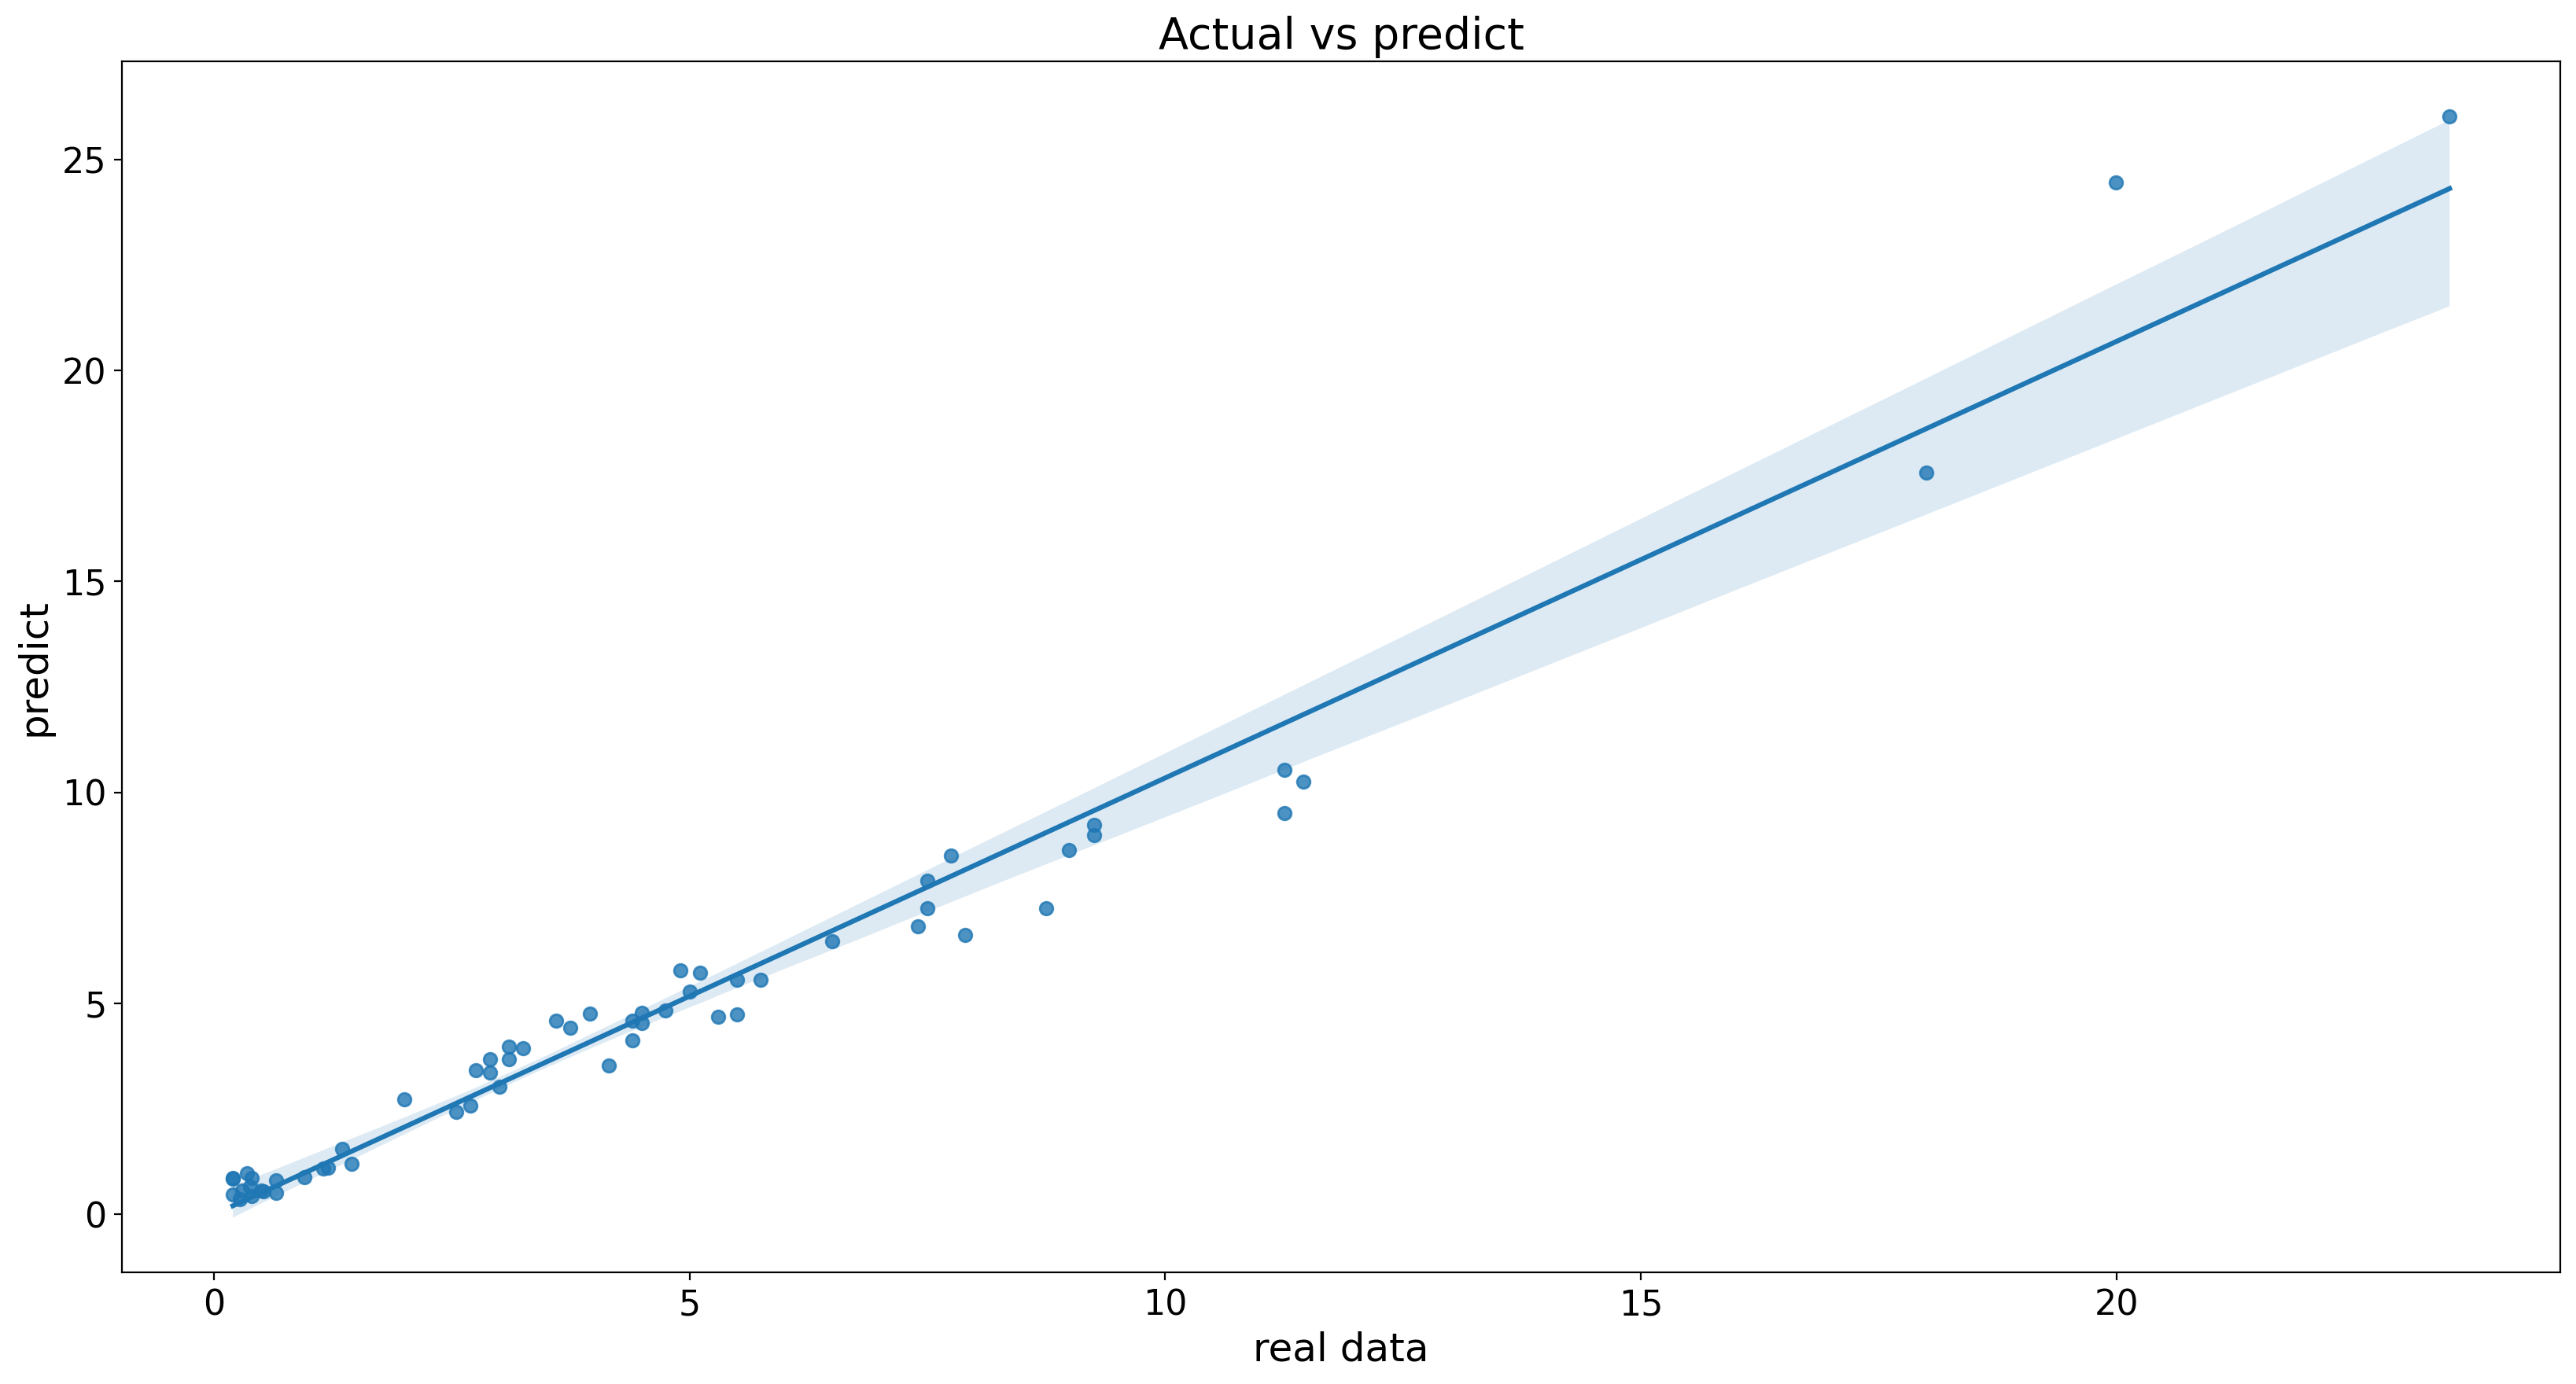

In [274]:
plt.figure(figsize=(20, 10), dpi=200)
sns.regplot(x=y_test, y=y_pred)
plt.title("Actual vs predict", fontsize=20)
plt.xlabel("real data", fontsize=18)
plt.ylabel("predict", fontsize=18)
plt.tick_params(axis="both", labelsize=16)
plt.show()

In [275]:
df5 = x_test
df5

,Present_Price,Kms_Driven,Present_Kms,Fuel_Type,Present_Fuel,Seller_Type,Transmission,Owner,Age,Present_Price_age
113,1.400,35000,49000.00,2,2.800,3,2,0,3,4.200
177,0.570,24000,13680.00,2,1.140,3,3,0,3,1.710
12,9.940,15000,149100.00,2,19.880,2,3,0,4,39.760
221,6.790,32000,217280.00,2,13.580,2,3,0,6,40.740
208,8.100,3435,27823.50,2,16.200,2,2,0,2,16.200
75,6.800,36000,244800.00,2,13.600,2,2,0,4,27.200
213,6.790,31604,214591.16,2,13.580,2,2,0,8,54.320
175,0.787,75000,59025.00,2,1.574,3,2,0,8,6.296
191,0.570,25000,14250.00,2,1.140,3,2,1,7,3.990
219,9.400,36000,338400.00,2,18.800,2,2,0,7,65.800


In [276]:
df5.insert(8, "y_test", y_test)
df5.insert(9, "y_pred", y_pred)
df5

,Present_Price,Kms_Driven,Present_Kms,Fuel_Type,Present_Fuel,Seller_Type,Transmission,Owner,y_test,y_pred,Age,Present_Price_age
113,1.400,35000,49000.00,2,2.800,3,2,0,1.15,1.077760,3,4.200
177,0.570,24000,13680.00,2,1.140,3,3,0,0.35,0.963307,3,1.710
12,9.940,15000,149100.00,2,19.880,2,3,0,7.50,7.251159,4,39.760
221,6.790,32000,217280.00,2,13.580,2,3,0,4.50,4.522369,6,40.740
208,8.100,3435,27823.50,2,16.200,2,2,0,7.90,6.612814,2,16.200
75,6.800,36000,244800.00,2,13.600,2,2,0,3.95,4.758269,4,27.200
213,6.790,31604,214591.16,2,13.580,2,2,0,2.90,3.362059,8,54.320
175,0.787,75000,59025.00,2,1.574,3,2,0,0.38,0.649642,8,6.296
191,0.570,25000,14250.00,2,1.140,3,2,1,0.20,0.850479,7,3.990
219,9.400,36000,338400.00,2,18.800,2,2,0,4.50,4.782241,7,65.800


In [277]:
df5.sort_values(by="Present_Price", inplace=True)

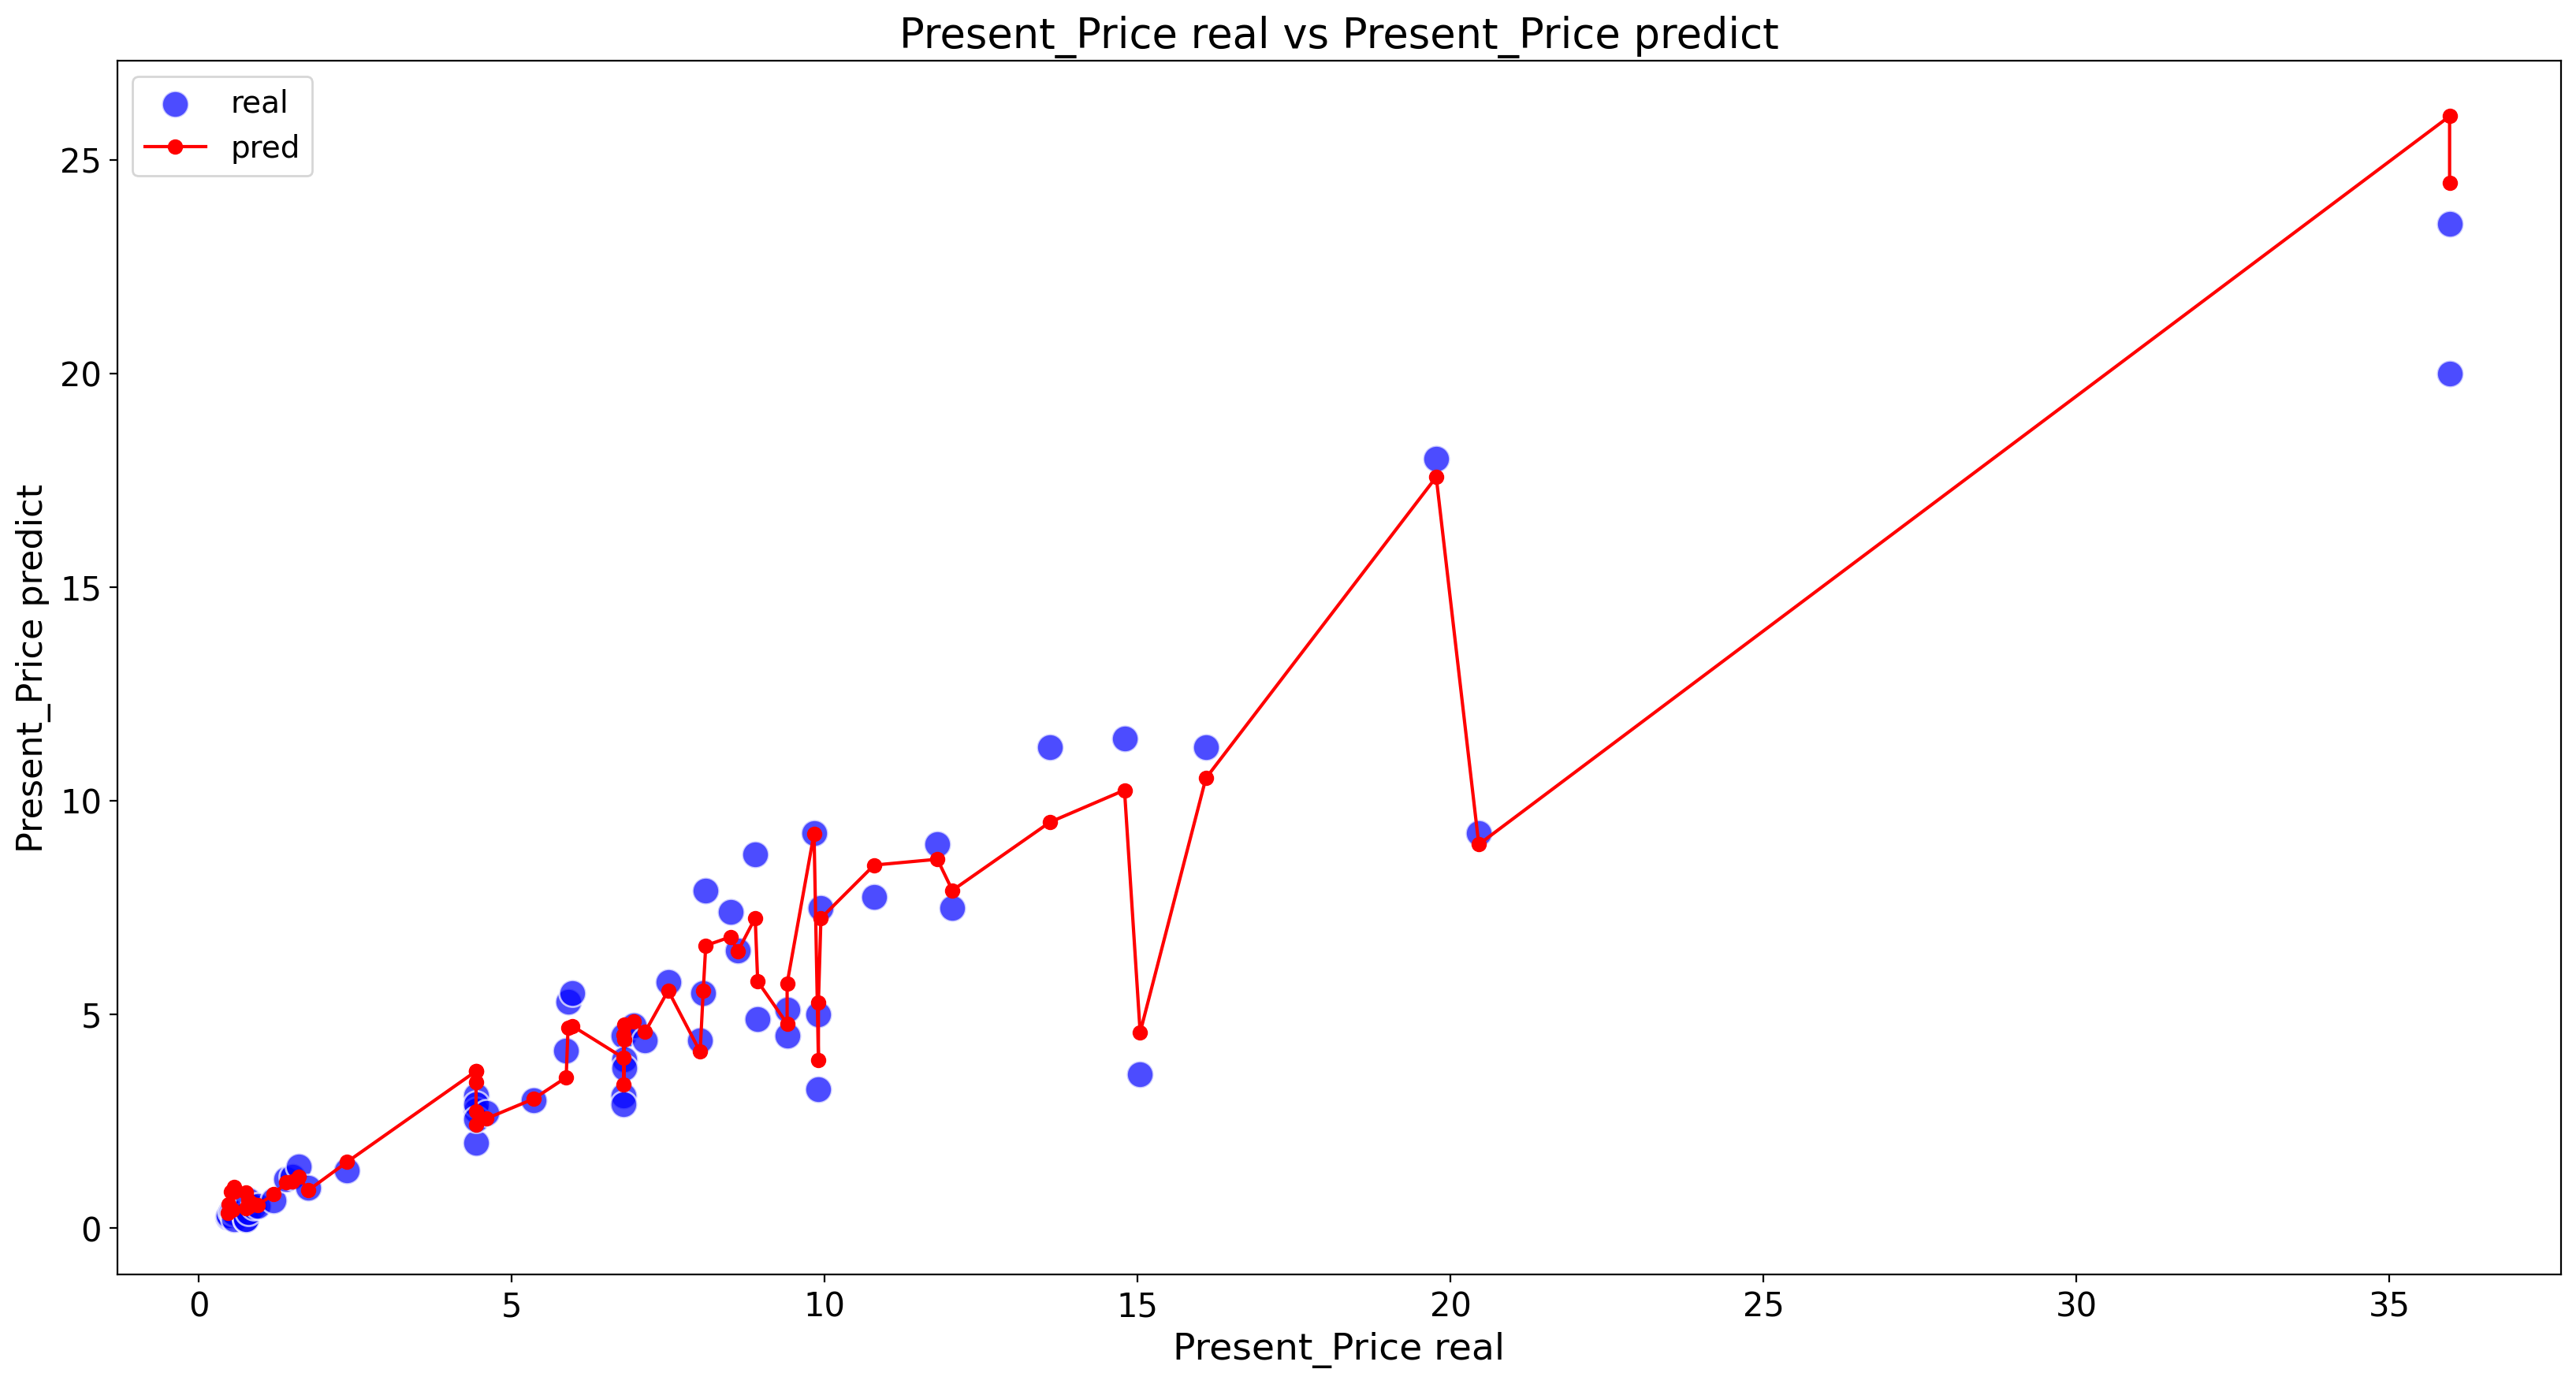

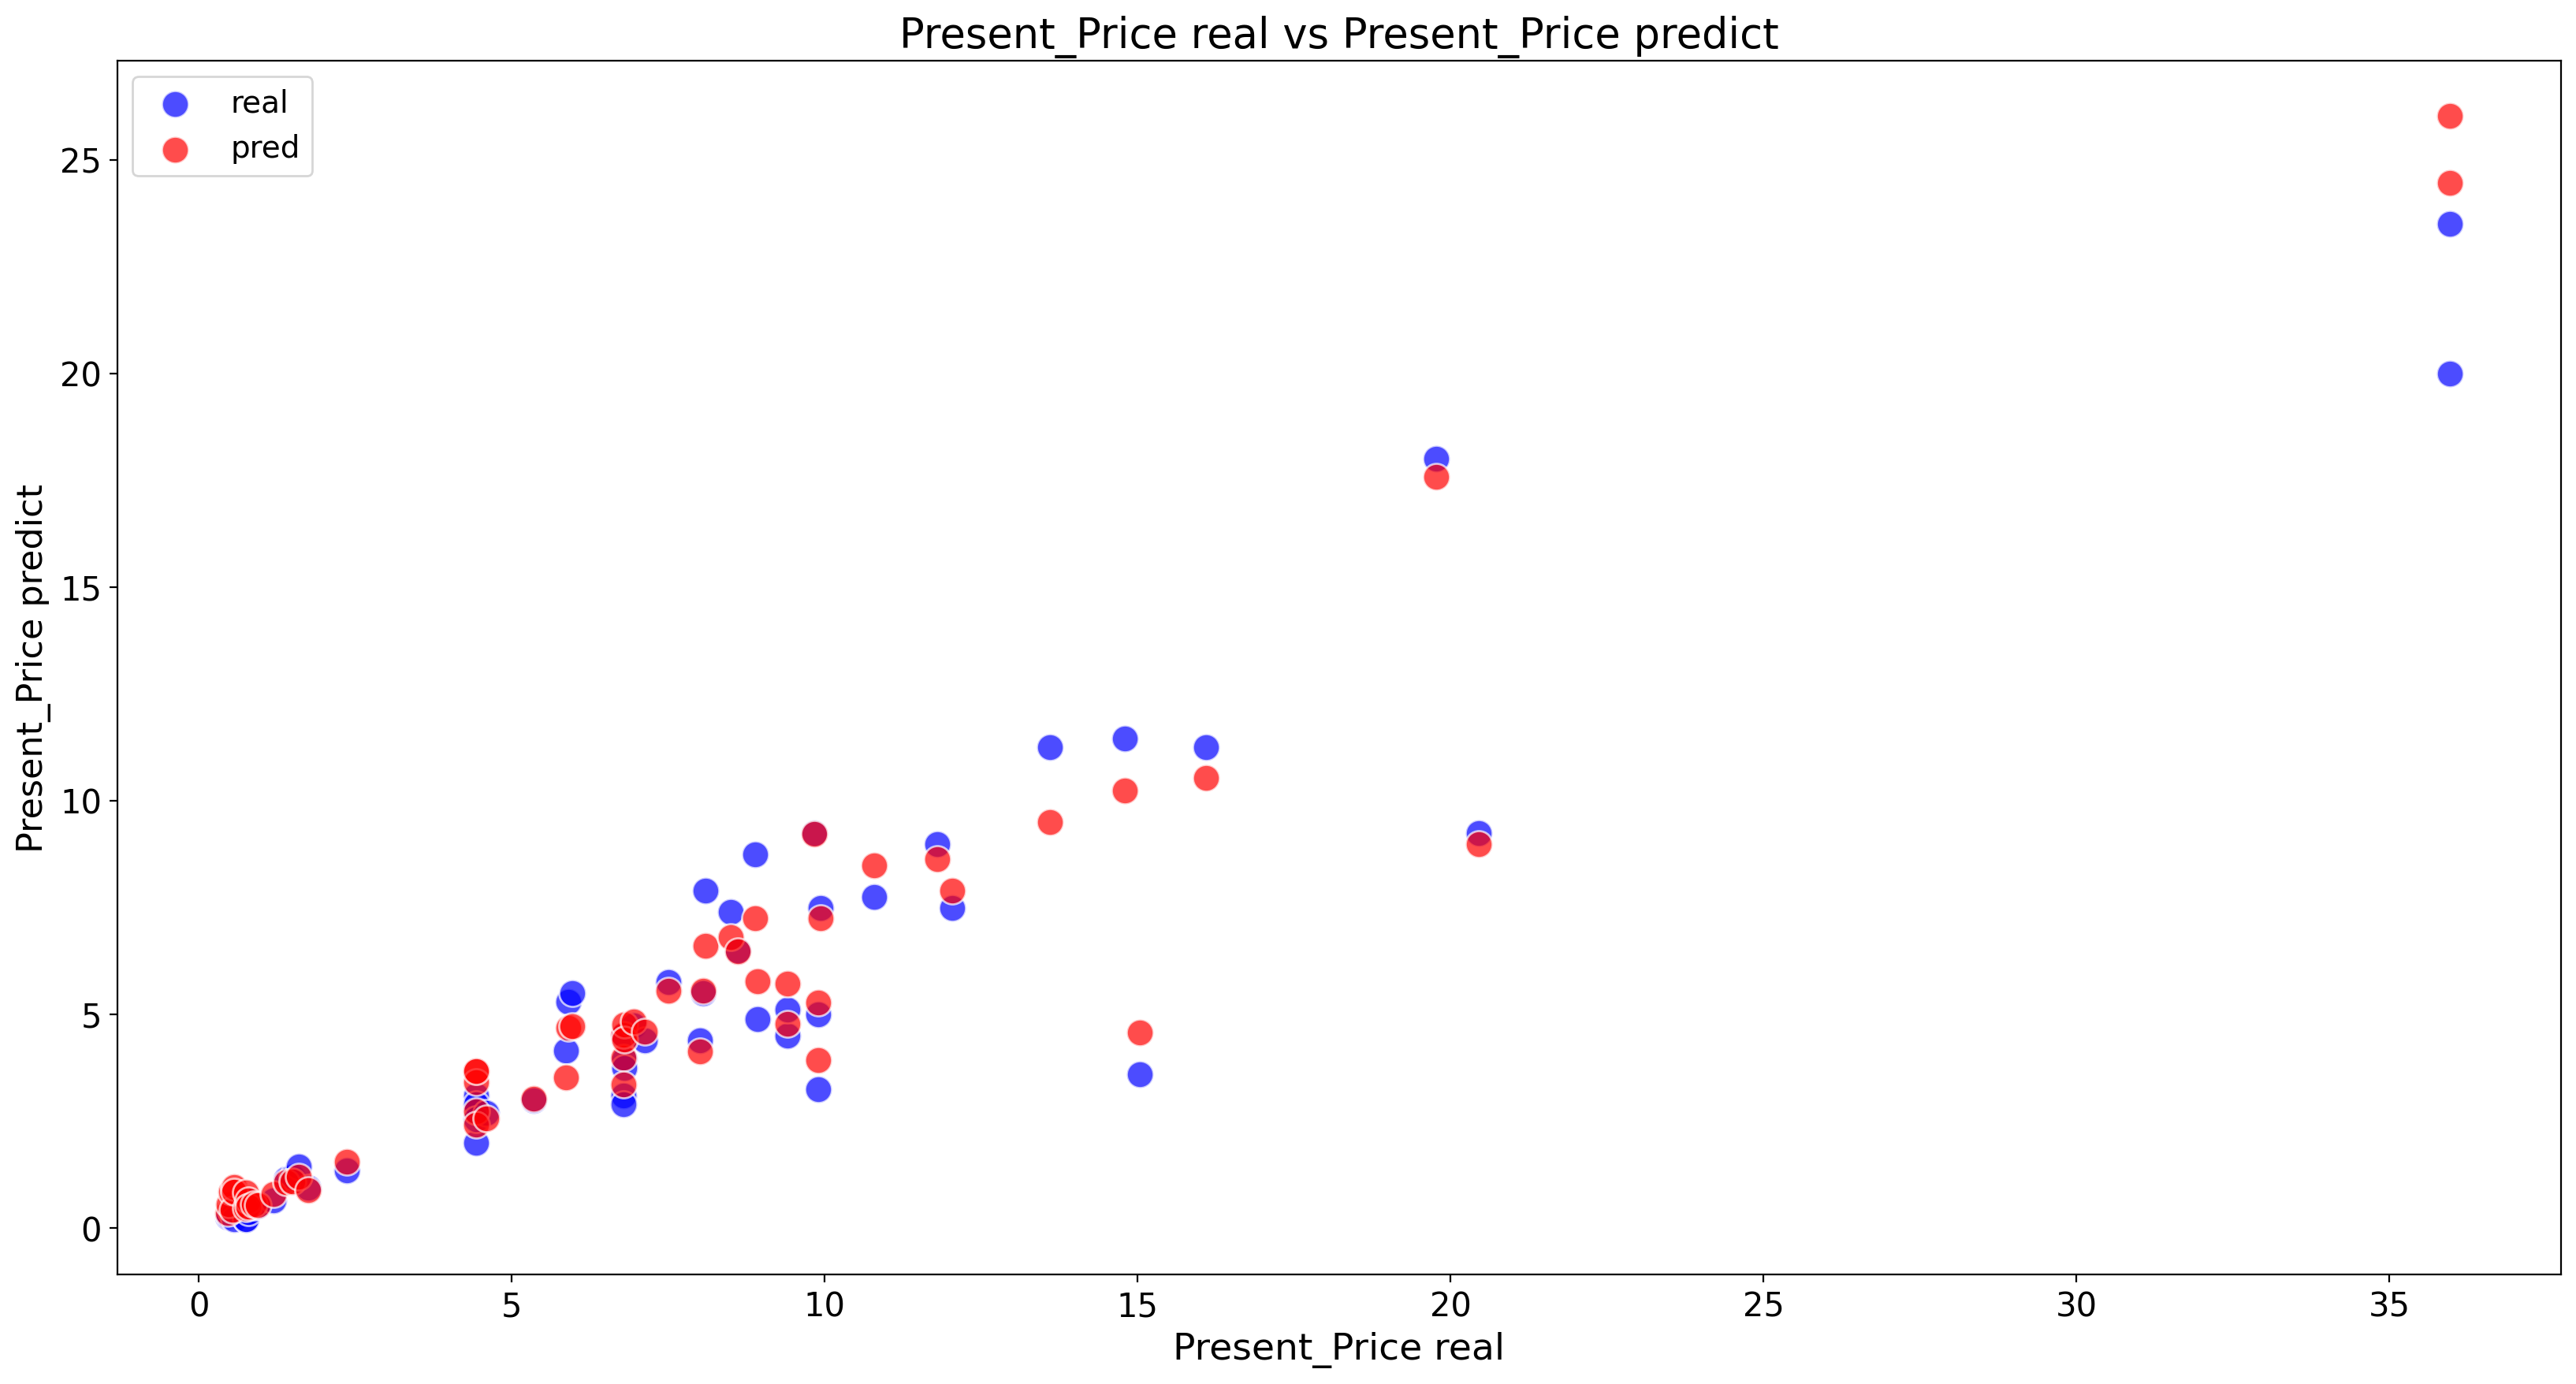

In [278]:
plt.figure(figsize=(20, 10), dpi=200)
sns.scatterplot(
    x=df5["Present_Price"],
    y=df5["y_test"],
    s=150,
    color="blue",
    alpha=0.7,
    label="real",
)
plt.plot(df5["Present_Price"], df5["y_pred"], color="red", marker="o", label="pred")
plt.title("Present_Price real vs Present_Price predict", fontsize=19)
plt.xlabel("Present_Price real", fontsize=17)
plt.ylabel("Present_Price predict", fontsize=16)
plt.tick_params(axis="both", labelsize=15)
plt.legend(title_fontsize=15, fontsize=14)
plt.show()
plt.figure(figsize=(20, 10), dpi=200)
sns.scatterplot(
    x=df5["Present_Price"],
    y=df5["y_test"],
    s=150,
    color="blue",
    alpha=0.7,
    label="real",
)
sns.scatterplot(
    x=df5["Present_Price"], y=df5["y_pred"], color="red", s=150, alpha=0.7, label="pred"
)
plt.title("Present_Price real vs Present_Price predict", fontsize=19)
plt.xlabel("Present_Price real", fontsize=17)
plt.ylabel("Present_Price predict", fontsize=16)
plt.tick_params(axis="both", labelsize=15)
plt.legend(title_fontsize=15, fontsize=14)
plt.show()

In [279]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.1, random_state=0
)  # 90/10

In [280]:
model_12 = LinearRegression()
model_12.fit(x_train, y_train)

LinearRegression()

In [281]:
y_pred = model_12.predict(x_test)

In [282]:
print(f"model_12 coef:\n{model_12.coef_}")
print(f"model_12 intercept:\n{model_12.intercept_}")

model_12 coef:
[ 6.39440645e-01  3.50916850e-06 -1.22102925e-06 -1.99435845e-01
  1.04765273e-01 -6.57569155e-01  4.19135323e-01  3.71776848e-01
  1.07891933e-02 -5.59491441e-02]
model_12 intercept:
1.527076819524896


In [283]:
print(f"mean absolute error 'model_12':\n{mean_absolute_error(y_test, y_pred)}")
print(f"mean squared error 'model_12':\n{mean_squared_error(y_test, y_pred)}")
print(f"root mean squared error 'model_12':\n{root_mean_squared_error(y_test, y_pred)}")
print(f"r2 score 'model_12':\n{r2_score(y_test, y_pred)}")

mean absolute error 'model_12':
0.5427861891283392
mean squared error 'model_12':
0.5063421847650263
root mean squared error 'model_12':
0.71157725143868
r2 score 'model_12':
0.9809833765865198


In [284]:
df6 = x_test
df6

,Present_Price,Kms_Driven,Present_Kms,Fuel_Type,Present_Fuel,Seller_Type,Transmission,Owner,Age,Present_Price_age
113,1.400,35000,49000.00,2,2.800,3,2,0,3,4.200
177,0.570,24000,13680.00,2,1.140,3,3,0,3,1.710
12,9.940,15000,149100.00,2,19.880,2,3,0,4,39.760
221,6.790,32000,217280.00,2,13.580,2,3,0,6,40.740
208,8.100,3435,27823.50,2,16.200,2,2,0,2,16.200
75,6.800,36000,244800.00,2,13.600,2,2,0,4,27.200
213,6.790,31604,214591.16,2,13.580,2,2,0,8,54.320
175,0.787,75000,59025.00,2,1.574,3,2,0,8,6.296
191,0.570,25000,14250.00,2,1.140,3,2,1,7,3.990
219,9.400,36000,338400.00,2,18.800,2,2,0,7,65.800


In [285]:
df6.insert(10, "y_test", y_test)
df6.insert(11, "y_pred", y_pred)

In [286]:
df6.sort_values(by="Present_Price", inplace=True)

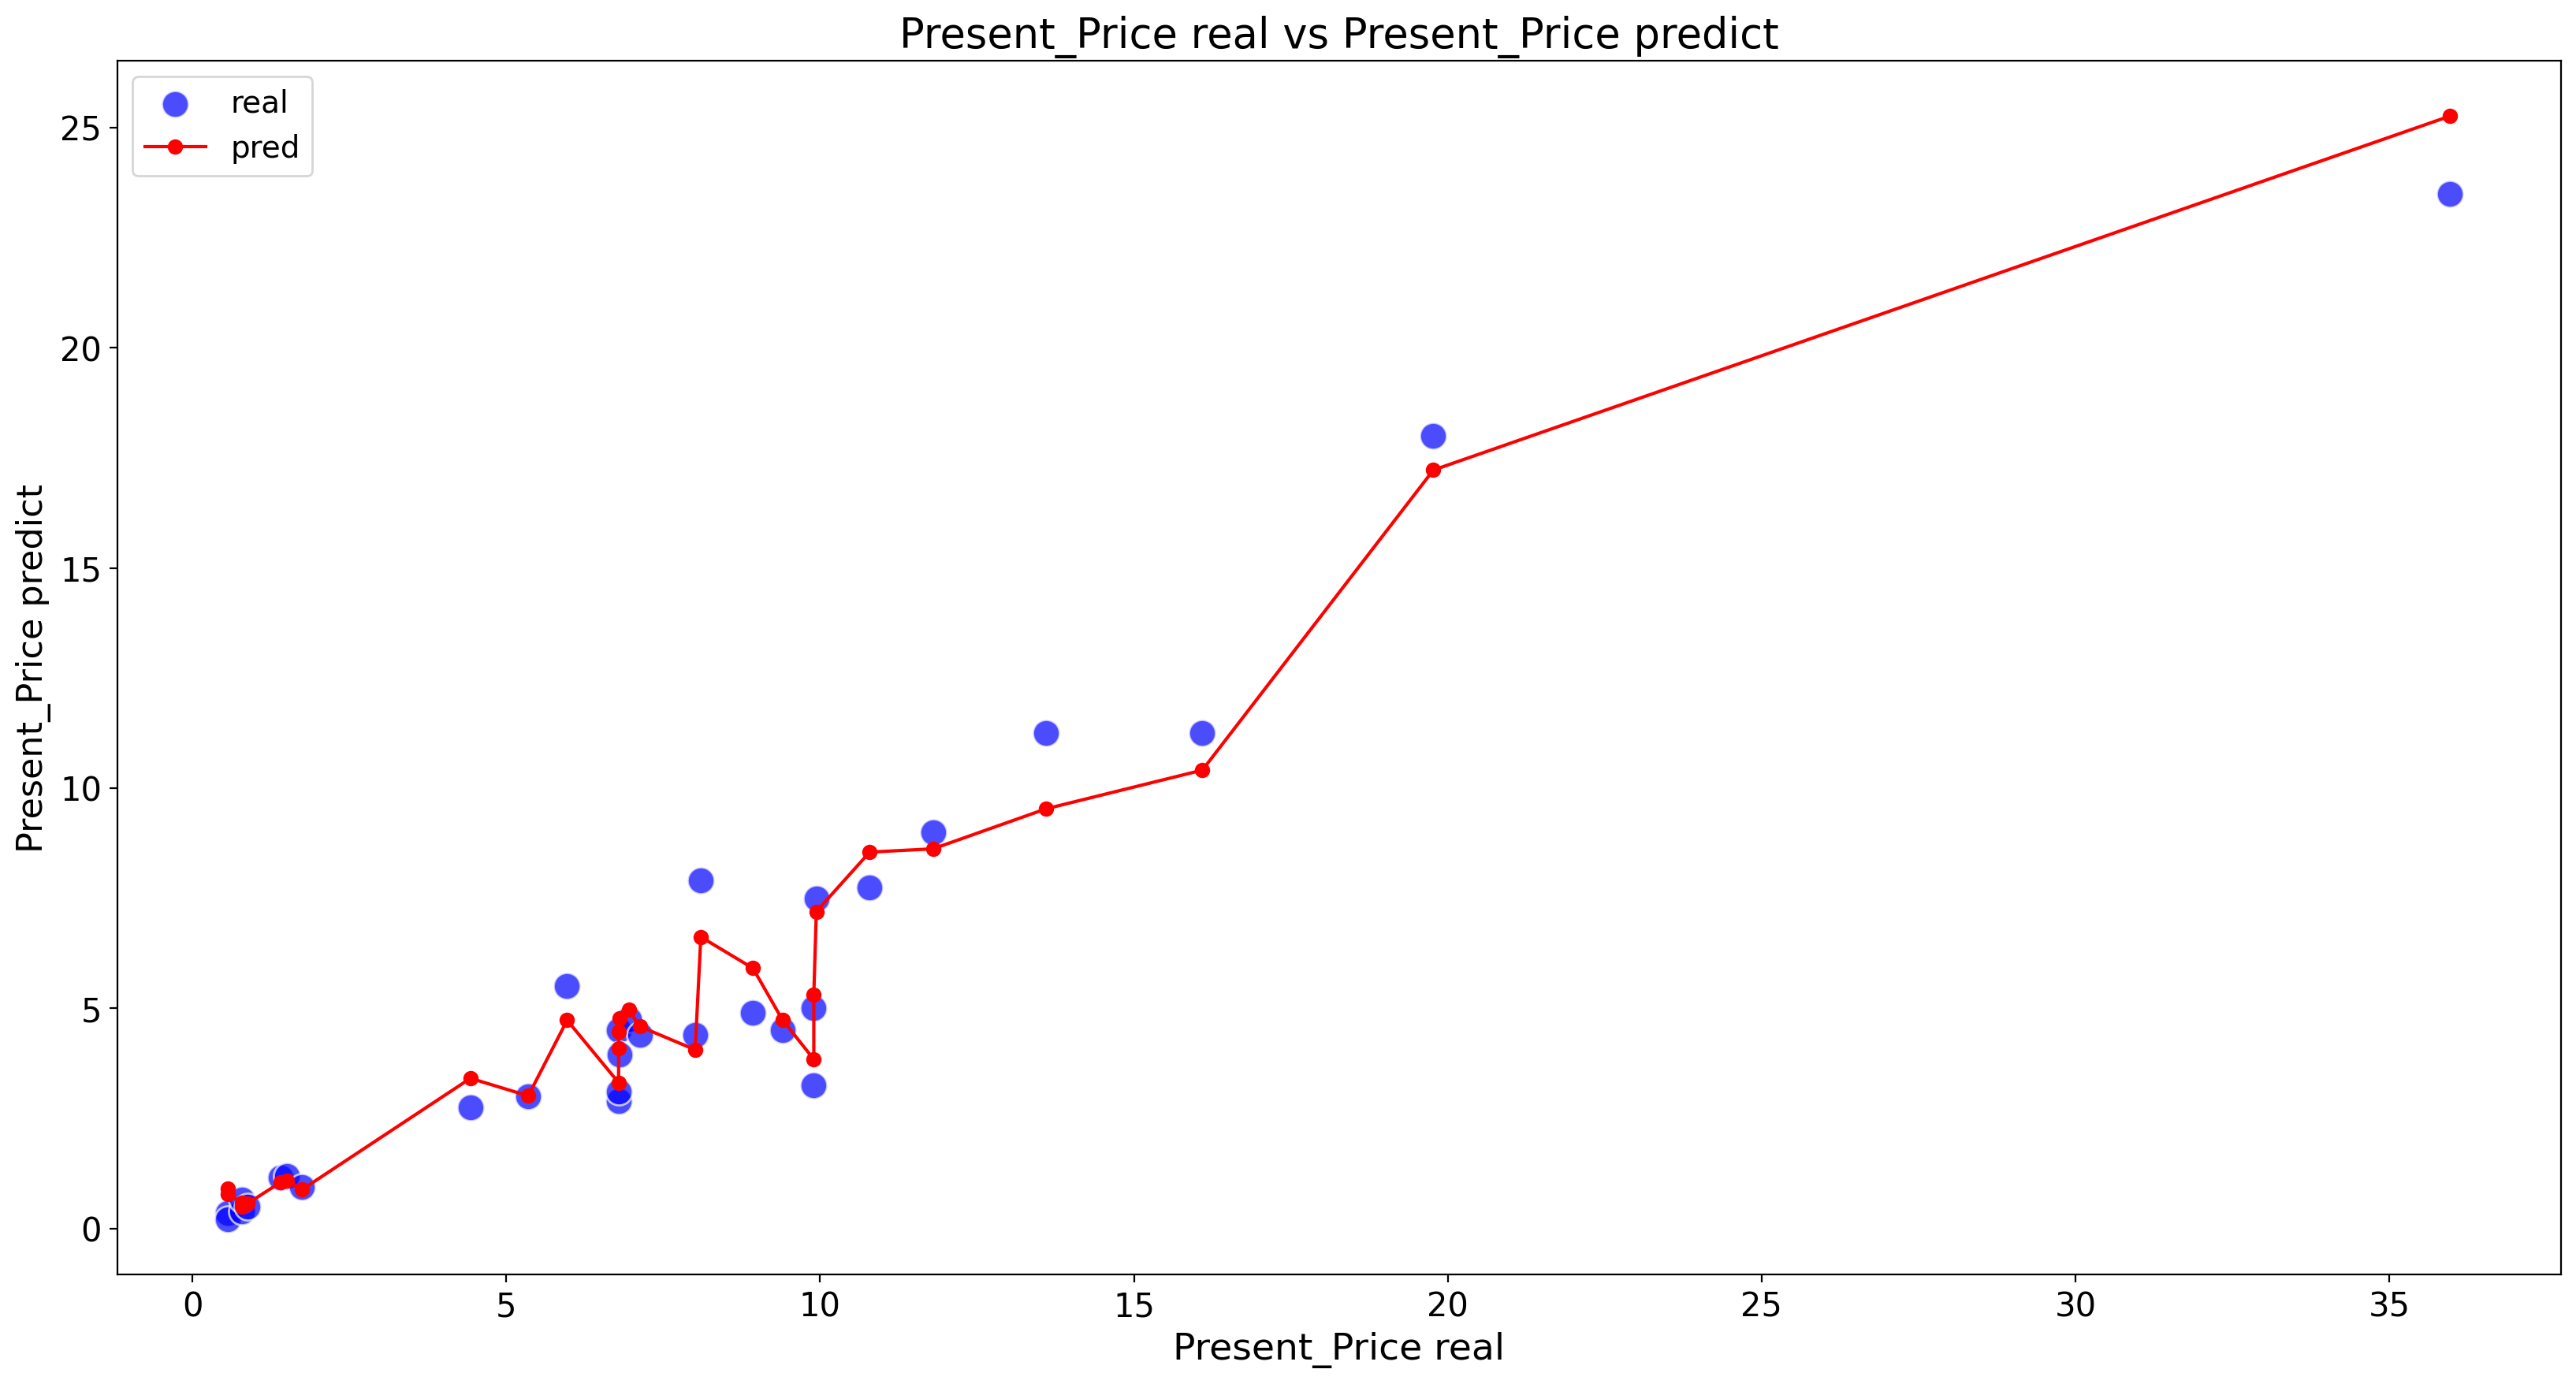

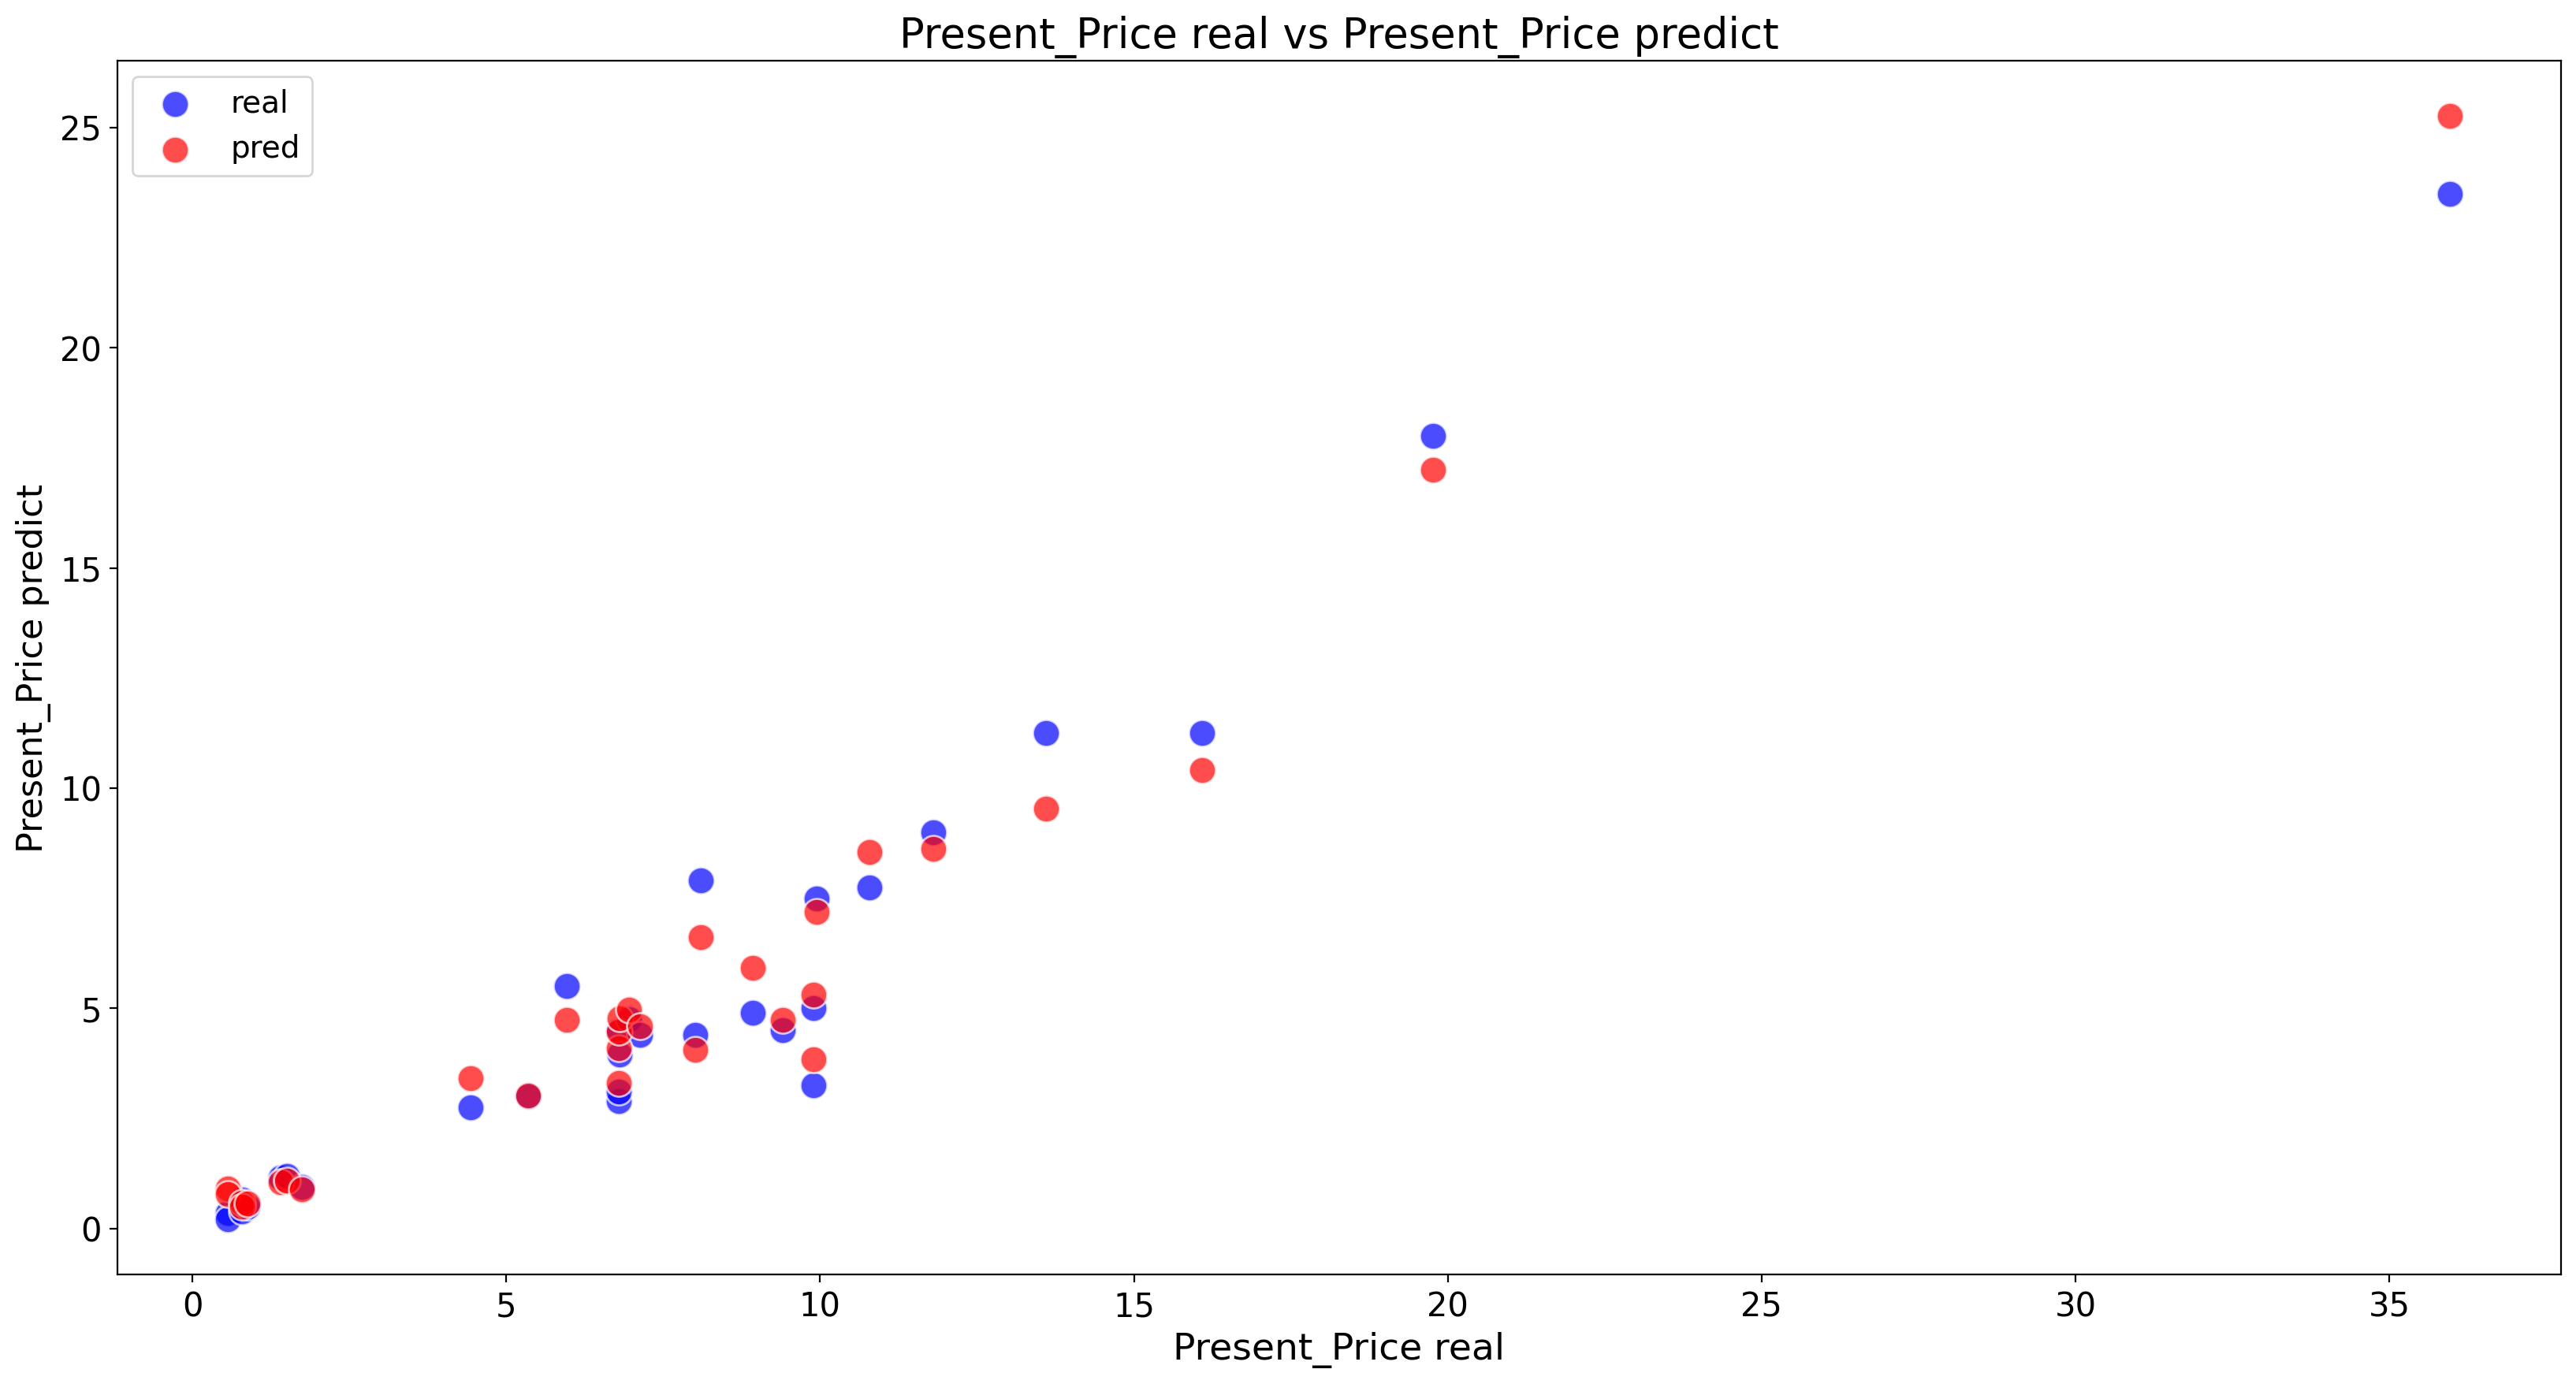

In [287]:
plt.figure(figsize=(20, 10), dpi=200)
sns.scatterplot(
    x=df6["Present_Price"],
    y=df6["y_test"],
    s=150,
    color="blue",
    alpha=0.7,
    label="real",
)
plt.plot(df6["Present_Price"], df6["y_pred"], color="red", marker="o", label="pred")
plt.title("Present_Price real vs Present_Price predict", fontsize=19)
plt.xlabel("Present_Price real", fontsize=17)
plt.ylabel("Present_Price predict", fontsize=16)
plt.tick_params(axis="both", labelsize=15)
plt.legend(title_fontsize=15, fontsize=14)
plt.show()
plt.figure(figsize=(20, 10), dpi=200)
sns.scatterplot(
    x=df6["Present_Price"],
    y=df6["y_test"],
    s=150,
    color="blue",
    alpha=0.7,
    label="real",
)
sns.scatterplot(
    x=df6["Present_Price"], y=df6["y_pred"], color="red", s=150, alpha=0.7, label="pred"
)
plt.title("Present_Price real vs Present_Price predict", fontsize=19)
plt.xlabel("Present_Price real", fontsize=17)
plt.ylabel("Present_Price predict", fontsize=16)
plt.tick_params(axis="both", labelsize=15)
plt.legend(title_fontsize=15, fontsize=14)
plt.show()

In [288]:
scaler=MinMaxScaler(feature_range=(0, 1)) 
df7 = df2.copy(deep=True)
df7

,Selling_Price,Present_Price,Kms_Driven,Present_Kms,Fuel_Type,Present_Fuel,Seller_Type,Transmission,Owner,Age,Present_Price_age
0,3.35,5.59,27000,150930.0,2,11.18,2,2,0,5,27.95
1,4.75,9.54,43000,410220.0,3,28.62,2,2,0,6,57.24
2,7.25,9.85,6900,67965.0,2,19.70,2,2,0,2,19.70
3,2.85,4.15,5200,21580.0,2,8.30,2,2,0,8,33.20
4,4.60,6.87,42450,291631.5,3,20.61,2,2,0,5,34.35
...,...,...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,394260.8,3,34.80,2,2,0,3,34.80
297,4.00,5.90,60000,354000.0,2,11.80,2,2,0,4,23.60
298,3.35,11.00,87934,967274.0,2,22.00,2,2,0,10,110.00
299,11.50,12.50,9000,112500.0,3,37.50,2,2,0,2,25.00


## Let's change the size of the training data.

In [289]:
df7[df7.columns[1:]] = scaler.fit_transform(df7[df7.columns[1:]])
df7

,Selling_Price,Present_Price,Kms_Driven,Present_Kms,Fuel_Type,Present_Fuel,Seller_Type,Transmission,Owner,Age,Present_Price_age
0,3.35,0.147868,0.124706,0.036461,0.0,0.098284,0.0,0.0,0.0,0.266667,0.087586
1,4.75,0.258698,0.200000,0.099212,0.5,0.260910,0.0,0.0,0.0,0.333333,0.182847
2,7.25,0.267396,0.030118,0.016383,0.0,0.177732,0.0,0.0,0.0,0.066667,0.060754
3,2.85,0.107464,0.022118,0.005157,0.0,0.071429,0.0,0.0,0.0,0.466667,0.104661
4,4.60,0.183782,0.197412,0.070512,0.5,0.186218,0.0,0.0,0.0,0.266667,0.108401
...,...,...,...,...,...,...,...,...,...,...,...
296,9.50,0.316498,0.157591,0.095349,0.5,0.318538,0.0,0.0,0.0,0.133333,0.109864
297,4.00,0.156566,0.280000,0.085606,0.0,0.104066,0.0,0.0,0.0,0.200000,0.073438
298,3.35,0.299663,0.411454,0.234024,0.0,0.199179,0.0,0.0,0.0,0.600000,0.354441
299,11.50,0.341751,0.040000,0.027161,0.5,0.343715,0.0,0.0,0.0,0.066667,0.077991


In [290]:
x = df7.drop(columns=["Selling_Price"])
y = df7["Selling_Price"]

In [291]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=0)

In [292]:
model_13 = LinearRegression()
model_13.fit(x_train, y_train)

LinearRegression()

In [293]:
y_pred = model_13.predict(x_test)

In [294]:
print(f"model_11 coef:\n{model_13.coef_}")
print(f"model_11 intercept:\n{model_13.intercept_}")

model_11 coef:
[ 22.78966458   0.74569831  -5.04539055  -0.39887169  11.23502793
  -0.65756915   0.41913532   1.11533054   0.1618379  -17.20268335]
model_11 intercept:
0.8781542196797711


In [295]:
print(f"mean absolute error 'model_13':\n{mean_absolute_error(y_test, y_pred)}")
print(f"mean squared error 'model_13':\n{mean_squared_error(y_test, y_pred)}")
print(f"root mean squared error 'model_13':\n{root_mean_squared_error(y_test, y_pred)}")
print(f"r2 score 'model_13':\n{r2_score(y_test, y_pred)}")

mean absolute error 'model_13':
0.5427861891278376
mean squared error 'model_13':
0.5063421847647512
root mean squared error 'model_13':
0.7115772514384866
r2 score 'model_13':
0.9809833765865301


The model has improved a lot

In [296]:
car = pd.DataFrame(data={
    "Present_Price":[11.22],
    "Kms_Driven":[42000],
    "Present_Kms":[11.22 * 42000],
    "Fuel_Type":[2],
    "Present_Fuel":[2 * 11.22],
     "Seller_Type":[2],
     "Transmission":[2],
     "Owner":[1],
     "Age":[10],
     "Present_Price_age":[10 * 11.22]
})
car

,Present_Price,Kms_Driven,Present_Kms,Fuel_Type,Present_Fuel,Seller_Type,Transmission,Owner,Age,Present_Price_age
0,11.22,42000,471240.0,2,22.44,2,2,1,10,112.2


In [297]:
print(model_12.predict(car))

[3.9509563]
